# Protocolo interpolativo común para modelos PEMS-PINN de NOx y CO — R1

**Propósito:** construir una única partición intradominio para los modelos posteriores
de NOx y CO utilizando exclusivamente nueve variables operativas.

**Alcance:** holdout interpolativo X-aware y y-blind. No demuestra estabilidad
prospectiva, degradación futura, extrapolación, certificación PEMS/CEMS, RATA ni
homologación regulatoria.

**Entradas:** `data/raw/gt_2011.csv` a `gt_2015.csv`.

**Salidas:** asignación DEV/TEST, cinco folds internos, envolvente kNN, diagnósticos,
auditorías y manifiestos FROZEN en
`models/interp/work_pinn_interp_protocol/`.

**Entorno previsto:** Google Colab, con la raíz
`/content/drive/MyDrive/Turbine_Emissions_PINN`.

**Estado:** protocolo R1 FROZEN. La organización sigue el Manual R4; la metodología,
las semillas, los límites y los contratos de artefactos no se modifican.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-01 | entorno, ruta, configuración e inicialización |
| SEC-02 | carga X-only y control de esquema |
| SEC-03 | autocorrelación, bloques y anclas operativas |
| SEC-04 | partición externa DEV/TEST |
| SEC-05 | sensibilidad de la envolvente kNN |
| SEC-06 | cinco folds internos agrupados |
| SEC-07 | diagnósticos y visualizaciones |
| SEC-08 | comprobaciones finales de integridad |
| SEC-09 | persistencia, congelamiento y cierre |

### Registro editorial de R1

- Se incorporaron etiquetas estables `SEC`, `C`, `ALG`, `CFG`, `CHK`, `ART`, `FIG` y `OUT`.
- Cada celda no trivial declara objetivo, entradas, salidas y control asociado.
- La ruta de Drive y las salidas canónicas quedan visibles en SEC-01.
- El orden y el contenido ejecutable del algoritmo R1 se preservan.


## SEC-01 — Entorno, configuración e inicialización

La ejecución parte de una raíz explícita y deriva todas las salidas permanentes de la estructura canónica de Drive.

### C-01.01 / CFG-01 — Preparación del entorno y raíz de Drive

**Objetivo:** declarar la única ruta editable, instalar dependencias ausentes y montar Drive en Colab.
**Entradas:** runtime de Python y `PROJECT_ROOT_PATH`.
**Salidas:** dependencias disponibles e indicador `IN_COLAB`.
**Control:** CFG-01 — editar únicamente `PROJECT_ROOT_PATH` si cambia la carpeta del proyecto.


In [1]:
# [C-01.01] Preparación del entorno y raíz de Drive

# --- CONFIGURACIÓN PRINCIPAL DE GOOGLE DRIVE ---
# Modifique únicamente esta ruta si el proyecto está en otra carpeta.
PROJECT_ROOT_PATH = r"C:\ChatGPT-Work\Walk_Forward R8"

import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "psutil": "psutil",
}
missing_packages = [
    package
    for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

print({"entorno": "Colab" if IN_COLAB else "local", "paquetes_instalados": missing_packages})


{'entorno': 'local', 'paquetes_instalados': []}


### C-01.02 / CFG-02 — Imports y configuración congelada R1

**Objetivo:** declarar dependencias, semillas, variables, umbrales y límites iterativos en una sola etapa visible.
**Entradas:** dependencias preparadas en C-01.01.
**Salidas:** constantes del protocolo y ruta `models/interp/work_pinn_interp_protocol`.
**Control:** CFG-02 — no modificar decisiones R1 por motivos de estilo.


In [2]:
# [C-01.02] Imports y configuración congelada R1

from __future__ import annotations

import csv
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import random
import sys
import tempfile
import time
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

PROTOCOL_VERSION = "INTERP_PROTOCOL_R1"
PROTOCOL_FREEZE_UTC = os.environ.get(
    "PEMS_PINN_INTERP_FREEZE_UTC",
    "2026-08-11T00:00:00Z",
)
SPLIT_SEED = 42
TEST_TARGET_FRACTION = 0.20
TEST_FRACTION_MIN = 0.18
TEST_FRACTION_MAX = 0.22
N_FOLDS = 5
FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
PROTECTED_TARGETS = ["CO", "NOX"]
YEARS = [2011, 2012, 2013, 2014, 2015]
EXPECTED_TOTAL_ROWS = 36_733
KNN_K = 20
KNN_QUANTILE = 0.99
BLOCK_SIZE_MODE = "AUTO"
BLOCK_CANDIDATES = [12, 24, 48, 72, 168]
KNN_SENSITIVITY_K = [10, 20, 30]
KNN_SENSITIVITY_Q = [0.975, 0.99, 0.995]
MAX_SPLIT_CANDIDATES = 80
MAX_REPAIR_ITERATIONS = 29
MAX_FOLD_PROMOTION_ITERATIONS = 49

CANONICAL_OUTPUT_RELATIVE_PATH = Path("models") / "interp" / "work_pinn_interp_protocol"


### C-01.03 — Utilidades de trazabilidad y escritura atómica

**Objetivo:** proveer serialización canónica, hashes SHA-256 y persistencia segura.
**Entradas:** valores, tablas y rutas de salida.
**Salidas:** texto, JSON y CSV UTF-8 escritos atómicamente.
**Control:** CHK-01 — los archivos se reemplazan solo después de completar su escritura.


In [3]:
# [C-01.03] Utilidades de trazabilidad y escritura atómica

# Estas utilidades mantienen rutas portables y escrituras atómicas.


def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def canonical_json(value) -> str:
    return json.dumps(
        value, ensure_ascii=False, sort_keys=True, separators=(",", ":"), default=str
    )


def sha256_bytes(value: bytes) -> str:
    return hashlib.sha256(value).hexdigest()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def atomic_text(path: Path, text: str) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fd, tmp_name = tempfile.mkstemp(prefix=path.name + ".", suffix=".tmp", dir=path.parent)
    os.close(fd)
    tmp = Path(tmp_name)
    try:
        tmp.write_text(text, encoding="utf-8", newline="\n")
        os.replace(tmp, path)
    finally:
        if tmp.exists():
            tmp.unlink()


def atomic_json(path: Path, value) -> None:
    atomic_text(
        path,
        json.dumps(value, ensure_ascii=False, sort_keys=True, indent=2, allow_nan=False) + "\n",
    )


def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fd, tmp_name = tempfile.mkstemp(prefix=path.name + ".", suffix=".tmp", dir=path.parent)
    os.close(fd)
    tmp = Path(tmp_name)
    try:
        frame.to_csv(tmp, index=False, lineterminator="\n", float_format="%.12g")
        os.replace(tmp, path)
    finally:
        if tmp.exists():
            tmp.unlink()


### C-01.04 / CHK-02 — Validación de la estructura canónica

**Objetivo:** comprobar tempranamente `data/raw/gt_2011.csv` a `gt_2015.csv` sin búsquedas heurísticas.
**Entradas:** `PROJECT_ROOT_PATH` y lista de años.
**Salidas:** raíz resuelta y rutas anuales verificadas.
**Control:** CHK-02 — detener con un mensaje accionable si falta un CSV.


In [4]:
# [C-01.04] Validación de la estructura canónica

def validate_project_root(project_root_path: str | Path) -> Path:
    """Valida la raíz configurada sin buscar ni adivinar directorios alternativos.

    La ruta se toma exclusivamente de ``PROJECT_ROOT_PATH``. El mensaje de error
    enumera los CSV ausentes para que el usuario pueda corregir una sola variable en
    la primera sección del notebook.
    """
    root = Path(project_root_path).expanduser().resolve()
    data_dir = root / "data" / "raw"
    missing_files = [
        data_dir / f"gt_{year}.csv"
        for year in YEARS
        if not (data_dir / f"gt_{year}.csv").is_file()
    ]
    if missing_files:
        missing_text = "\n".join(f"- {path}" for path in missing_files)
        raise FileNotFoundError(
            "PROJECT_ROOT_PATH no apunta a la estructura esperada de "
            "Turbine_Emissions_PINN. Corrija esa variable y vuelva a ejecutar.\n"
            f"Raíz configurada: {root}\n"
            f"CSV ausentes:\n{missing_text}"
        )
    return root


def locate_data_file(root: Path, year: int) -> Path:
    """Devuelve la ruta canónica del CSV anual dentro de ``data/raw``."""
    path = root / "data" / "raw" / f"gt_{year}.csv"
    if not path.is_file():
        raise FileNotFoundError(
            f"No se encontró {path}. Revise PROJECT_ROOT_PATH y la estructura de Drive."
        )
    return path.resolve()


### C-01.05 — Hashes de entrada e inicialización

**Objetivo:** crear carpetas canónicas y registrar identidad de datos y entorno antes del cálculo.
**Entradas:** raíz validada y cinco CSV.
**Salidas:** `PATHS`, hashes previos y manifiesto del entorno.
**Control:** CHK-03 — las entradas determinantes quedan identificadas antes de usarse.


In [5]:
# [C-01.05] Hashes de entrada e inicialización

def collect_data_hashes(root: Path) -> pd.DataFrame:
    """Calcula la identidad de los cinco CSV que determinan el protocolo."""
    rows = []
    for year in YEARS:
        path = locate_data_file(root, year)
        rows.append(
            {
                "year": year,
                "path": str(path.relative_to(root)),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
        )
    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def initialize_protocol(root: Path):
    """Prepara las salidas y registra el entorno reproducible."""
    output = root / CANONICAL_OUTPUT_RELATIVE_PATH
    paths = {name: output / name for name in ("audit", "manifests", "tables", "reports")}
    for path in paths.values():
        path.mkdir(parents=True, exist_ok=True)

    data_hashes = collect_data_hashes(root)
    atomic_csv(paths["audit"] / "INTERP_DATA_HASHES_BEFORE.csv", data_hashes)
    environment = {
        "protocol_version": PROTOCOL_VERSION,
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "python": sys.version,
        "platform": platform.platform(),
        "cpu_count_logical": psutil.cpu_count(logical=True),
        "cpu_count_physical": psutil.cpu_count(logical=False),
        "ram_gib": round(psutil.virtual_memory().total / 2**30, 3),
        "packages": {
            name: importlib.metadata.version(name)
            for name in [
                "numpy",
                "pandas",
                "scikit-learn",
                "scipy",
                "matplotlib",
                "psutil",
            ]
        },
        "in_colab": IN_COLAB,
    }
    atomic_json(paths["audit"] / "INTERP_ENVIRONMENT_MANIFEST.json", environment)
    return output, paths, data_hashes, environment


### C-01.06 / OUT-01 — Inicio de la ejecución reproducible

**Objetivo:** activar el cronómetro, inicializar el protocolo y mostrar la configuración efectiva.
**Entradas:** ruta y constantes R1.
**Salidas:** `PROJECT_ROOT`, `OUTPUT_DIR`, `PATHS` y resumen inicial.
**Control:** OUT-01 — configuración visible antes de procesar datos.


In [6]:
# [C-01.06] Inicio de la ejecución reproducible

RUN_STARTED = time.perf_counter()
PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
OUTPUT_DIR, PATHS, DATA_HASHES_BEFORE, ENVIRONMENT = initialize_protocol(PROJECT_ROOT)

display(
    pd.Series(
        {
            "versión": PROTOCOL_VERSION,
            "raíz del proyecto": str(PROJECT_ROOT),
            "semilla": SPLIT_SEED,
            "fracción TEST nominal": TEST_TARGET_FRACTION,
            "folds": N_FOLDS,
            "kNN": f"k={KNN_K}, q={KNN_QUANTILE}",
        },
        name="valor",
    ).to_frame()
)


,valor
versión,INTERP_PROTOCOL_R1
raíz del proyecto,C:\ChatGPT-Work\Walk_Forward R8
semilla,42
fracción TEST nominal,0.2
folds,5
kNN,"k=20, q=0.99"


## SEC-02 — Carga X-only e integridad de entradas

Los cinco CSV se validan por esquema y solo se cargan las nueve variables operativas autorizadas.

### C-02.01 / CHK-04 — Lectura exclusiva del encabezado

**Objetivo:** verificar nombres de columnas sin materializar valores protegidos.
**Entradas:** ruta de un CSV anual.
**Salidas:** lista ordenada de nombres de columnas.
**Control:** CHK-04 — CO y NOX se inspeccionan solo como nombres.


In [7]:
# [C-02.01] Lectura exclusiva del encabezado

# La selección usecols impide materializar los objetivos protegidos.


def read_header_only(path: Path) -> list[str]:
    with path.open("r", encoding="utf-8-sig", newline="") as handle:
        header = next(csv.reader(handle))
    return header


### C-02.02 / CHK-05 — Preflight y carga de variables operativas

**Objetivo:** validar esquema, finitud e identidad antes de concatenar los cinco años.
**Entradas:** CSV anuales y `FEATURES`.
**Salidas:** datos X-only, tabla preflight y auditoría de acceso a objetivos.
**Control:** CHK-05 — 36.733 filas, IDs únicos y cero valores CO/NOX leídos.


In [8]:
# [C-02.02] Preflight y carga de variables operativas

def preflight_and_load_x(root: Path, paths: dict):
    preflight_rows = []
    access_events = []
    frames = []
    global_position = 0
    for year in YEARS:
        path = locate_data_file(root, year)
        header = read_header_only(path)
        duplicates = sorted([name for name, count in Counter(header).items() if count > 1])
        missing_features = sorted(set(FEATURES) - set(header))
        missing_targets = sorted(set(PROTECTED_TARGETS) - set(header))
        access_events.append(
            {
                "year": year,
                "path": str(path.relative_to(root)),
                "operation": "HEADER_ONLY",
                "data_values_read": False,
                "columns": header,
            }
        )
        if duplicates or missing_features or missing_targets:
            raise ValueError(
                f"Esquema inválido {year}: duplicadas={duplicates}, "
                f"faltan_X={missing_features}, faltan_targets={missing_targets}"
            )
        frame = pd.read_csv(
            path, usecols=FEATURES, dtype={feature: "float64" for feature in FEATURES}
        )
        access_events.append(
            {
                "year": year,
                "path": str(path.relative_to(root)),
                "operation": "DATA_USECOLS",
                "data_values_read": True,
                "columns": FEATURES,
            }
        )
        if list(frame.columns) != FEATURES:
            frame = frame[FEATURES]
        values = frame.to_numpy(dtype=float)
        if not np.isfinite(values).all():
            raise ValueError(f"Valores faltantes o infinitos en entradas X de {year}")
        n = len(frame)
        frame.insert(0, "global_row_id", [f"{year}_{i:06d}" for i in range(n)])
        frame.insert(1, "year", year)
        frame.insert(2, "row_in_year", np.arange(n, dtype=int))
        frame.insert(
            3, "global_position", np.arange(global_position, global_position + n, dtype=int)
        )
        global_position += n
        frames.append(frame)
        preflight_rows.append(
            {
                "year": year,
                "path": str(path.relative_to(root)),
                "rows": n,
                "columns_in_header": len(header),
                "features_present": True,
                "protected_targets_present_in_header": True,
                "duplicate_columns": "",
                "missing_values_x": int(frame[FEATURES].isna().sum().sum()),
                "infinite_values_x": int((~np.isfinite(values)).sum()),
                "sha256": sha256_file(path),
            }
        )
    data = pd.concat(frames, ignore_index=True)
    if len(data) != EXPECTED_TOTAL_ROWS:
        raise RuntimeError(
            f"Se esperaban {EXPECTED_TOTAL_ROWS:,} filas y se observaron "
            f"{len(data):,}; no se ajusta silenciosamente el protocolo"
        )
    if not data["global_row_id"].is_unique or not data["global_position"].is_unique:
        raise AssertionError("Los identificadores reproducibles no son únicos")
    target_audit = {
        "status": "PASS",
        "protocol_version": PROTOCOL_VERSION,
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "protected_targets": PROTECTED_TARGETS,
        "protected_value_reads": 0,
        "header_only_reads": len(YEARS),
        "x_only_data_reads": len(YEARS),
        "read_csv_data_usecols": FEATURES,
        "events": access_events,
        "statement": (
            "Los nombres CO y NOX se verificaron únicamente en el encabezado; "
            "sus valores no se cargaron ni se resumieron."
        ),
    }
    atomic_csv(paths["audit"] / "INTERP_DATA_PREFLIGHT.csv", pd.DataFrame(preflight_rows))
    atomic_json(paths["audit"] / "INTERP_TARGET_ACCESS_AUDIT.json", target_audit)
    return data, pd.DataFrame(preflight_rows), target_audit


### C-02.03 / OUT-02 — Ejecución de la carga X-only

**Objetivo:** materializar las entradas autorizadas y presentar su control de calidad.
**Entradas:** raíz y rutas de auditoría.
**Salidas:** `DATA`, `DATA_PREFLIGHT` y `TARGET_ACCESS_AUDIT`.
**Control:** OUT-02 — resumen anual y declaración de ceguera de objetivos.


In [9]:
# [C-02.03] Ejecución de la carga X-only

print("Fase 1/5 · Verificación de esquema y carga X-only")
DATA, DATA_PREFLIGHT, TARGET_ACCESS_AUDIT = preflight_and_load_x(PROJECT_ROOT, PATHS)
display(DATA_PREFLIGHT[["year", "rows", "missing_values_x", "infinite_values_x", "sha256"]])
print(TARGET_ACCESS_AUDIT["statement"])


Fase 1/5 · Verificación de esquema y carga X-only


,year,rows,missing_values_x,infinite_values_x,sha256
0,2011,7411,0,0,d87ceef9aa59533cc7d924d10de241b1b06ecd11f9b26b...
1,2012,7628,0,0,be54b9d0e1a7de40c55d32fa489e75de892b000c066b5a...
2,2013,7152,0,0,13c437bb440ec2045bd12057e6654c41dd4107a661eac1...
3,2014,7158,0,0,c2a03c92c9c3207aad0c6be7de8d9b5b4bfa4720ad0efb...
4,2015,7384,0,0,9b08f35fde0d4b138232a605db4093c2b8bf9d6757e6f1...


Los nombres CO y NOX se verificaron únicamente en el encabezado; sus valores no se cargaron ni se resumieron.


## SEC-03 — Bloques y anclas operativas

El tamaño de bloque se deriva solo de X en el orden preservado de cada CSV; después se identifican extremos y estratos operativos.

### C-03.01 / ALG-01 / ALG-02 — Autocorrelación y selección del tamaño de bloque

**Objetivo:** estimar decorrelación mediante Wiener–Khinchin/FFT y escoger el candidato R1.
**Entradas:** datos X-only, retardos y `BLOCK_CANDIDATES`.
**Salidas:** ACF, diagnóstico de candidatos y regla de bloque.
**Control:** CHK-06 — lag válido, varianza suficiente y fallback explícito en 168 registros.


In [10]:
# [C-03.01] Autocorrelación y selección del tamaño de bloque

# El análisis temporal se aplica solo a X y no define una validación prospectiva.


def fft_acf(values: np.ndarray, max_lag: int = 168) -> np.ndarray:
    """Estima la autocorrelación normalizada mediante Wiener-Khinchin y FFT.

    Para una señal centrada ``x``, el teorema de Wiener-Khinchin permite obtener la
    autocovarianza como la transformada inversa del espectro de potencia::

        ACF(tau) = IFFT(FFT(x) * conjugate(FFT(x)))

    El relleno con ceros hasta al menos ``2*n - 1`` evita que la convolución circular
    mezcle el inicio y el final de la serie. Cada retardo se divide por ``n - tau``
    para corregir el número decreciente de pares disponibles y, finalmente, se
    normaliza por la autocovarianza en retardo cero.

    Args:
        values: Serie numérica unidimensional.
        max_lag: Máximo retardo, en registros, que se devolverá.

    Returns:
        Autocorrelaciones normalizadas desde el retardo cero hasta ``max_lag``.
    """
    values_array = np.asarray(values, dtype=float)
    if values_array.ndim != 1:
        raise ValueError("fft_acf requiere una serie unidimensional")
    if max_lag < 0 or max_lag >= len(values_array):
        raise ValueError("max_lag debe estar entre 0 y len(values) - 1")

    centered_values = values_array - values_array.mean()
    n_observations = len(centered_values)
    fft_length = 1 << (2 * n_observations - 1).bit_length()

    spectrum = np.fft.rfft(centered_values, n=fft_length)
    power_spectrum = spectrum * np.conjugate(spectrum)
    autocovariance = np.fft.irfft(power_spectrum, n=fft_length)[: max_lag + 1]
    pair_counts = np.arange(
        n_observations,
        n_observations - max_lag - 1,
        -1,
    )
    autocovariance = autocovariance / pair_counts
    if autocovariance[0] <= np.finfo(float).eps:
        raise ValueError("La serie no presenta varianza suficiente para calcular ACF")
    return autocovariance / autocovariance[0]


def select_block_size(
    data: pd.DataFrame,
    paths: dict[str, Path],
) -> tuple[int, pd.DataFrame, dict]:
    """Selecciona bloques indivisibles a partir de la decorrelación de X.

    Para cada combinación año-variable se obtiene la ACF con ``fft_acf`` y se busca
    el primer retardo cuya magnitud cae dentro de la banda aproximada de ruido blanco
    ``±1.96/sqrt(n_year)``. El percentil 75 de esos retardos resume de forma robusta
    las 45 combinaciones. El tamaño final es el primer valor de ``BLOCK_CANDIDATES``
    mayor o igual que ese resumen; si ninguno lo alcanza, se usa el mayor candidato.

    Returns:
        Tamaño seleccionado, tabla diagnóstica y regla metodológica congelada.
    """
    rows = []
    autocorrelation_curves = []
    decorrelation_lags = []
    fallback_count = 0

    for year in YEARS:
        year_features = data.loc[data.year == year, FEATURES]
        confidence_band = 1.96 / math.sqrt(len(year_features))

        for feature in FEATURES:
            autocorrelation = fft_acf(
                year_features[feature].to_numpy(),
                max_lag=168,
            )
            crossings = np.flatnonzero(np.abs(autocorrelation[1:]) <= confidence_band)
            if len(crossings):
                decorrelation_lag = int(crossings[0] + 1)
                used_fallback = False
            else:
                decorrelation_lag = 168
                used_fallback = True
                fallback_count += 1

            decorrelation_lags.append(decorrelation_lag)
            autocorrelation_curves.append(np.abs(autocorrelation))
            rows.append(
                {
                    "record_type": "acf",
                    "year": year,
                    "feature": feature,
                    "lag_decorrelation": decorrelation_lag,
                    "confidence_band": confidence_band,
                    "fallback_168": used_fallback,
                    "candidate_records": np.nan,
                    "n_blocks": np.nan,
                    "mean_block_rows": np.nan,
                }
            )

    curve_matrix = np.vstack(autocorrelation_curves)
    for lag in range(curve_matrix.shape[1]):
        rows.append(
            {
                "record_type": "acf_summary",
                "lag_records": lag,
                "median_abs_acf": float(np.median(curve_matrix[:, lag])),
                "q25_abs_acf": float(np.quantile(curve_matrix[:, lag], 0.25)),
                "q75_abs_acf": float(np.quantile(curve_matrix[:, lag], 0.75)),
            }
        )

    robust_lag = float(np.quantile(decorrelation_lags, 0.75))
    selected_records = next(
        (candidate for candidate in BLOCK_CANDIDATES if candidate >= robust_lag),
        BLOCK_CANDIDATES[-1],
    )

    for candidate in BLOCK_CANDIDATES:
        block_count = sum(
            math.ceil(int((data.year == year).sum()) / candidate) for year in YEARS
        )
        rows.append(
            {
                "record_type": "candidate",
                "year": np.nan,
                "feature": "ALL_X",
                "lag_decorrelation": robust_lag,
                "confidence_band": np.nan,
                "fallback_168": fallback_count > 0,
                "candidate_records": candidate,
                "n_blocks": block_count,
                "mean_block_rows": len(data) / block_count,
            }
        )

    diagnostics = pd.DataFrame(rows)
    atomic_csv(
        paths["tables"] / "INTERP_BLOCK_SIZE_DIAGNOSTICS.csv",
        diagnostics,
    )
    rule = {
        "mode": BLOCK_SIZE_MODE,
        "max_lag": 168,
        "confidence_band": "1.96/sqrt(n_year)",
        "robust_summary": "percentile_75",
        "robust_lag_records": robust_lag,
        "candidate_records": BLOCK_CANDIDATES,
        "selected_records": selected_records,
        "fallback_combinations": fallback_count,
        "unit": "consecutive_records_in_preserved_file_order",
        "interpretation": (
            "Control de redundancia local en registros consecutivos; no supone "
            "continuidad horaria, no demuestra independencia completa ni constituye "
            "embargo temporal."
        ),
    }
    return selected_records, diagnostics, rule


### C-03.02 / ALG-03 — Construcción de bloques, anclas y estratos

**Objetivo:** crear bloques indivisibles y conservar en DEV los extremos de las nueve variables.
**Entradas:** `DATA`, tamaño de bloque y configuración kNN.
**Salidas:** datos enriquecidos, bloques ancla y detalle de extremos.
**Control:** CHK-07 — operaciones X-only y bloques anuales reproducibles.


In [11]:
# [C-03.02] Construcción de bloques, anclas y estratos

def build_blocks_and_strata(data: pd.DataFrame, block_size: int):
    data = data.copy()
    data["block_number_in_year"] = (data["row_in_year"] // block_size).astype(int)
    data["block_id"] = data.apply(
        lambda row: f"Y{int(row.year)}_B{int(row.block_number_in_year):04d}", axis=1
    )
    extreme_rows = set()
    extreme_detail = []
    for feature in FEATURES:
        min_index = int(data[feature].idxmin())
        max_index = int(data[feature].idxmax())
        for kind, index in (("min", min_index), ("max", max_index)):
            extreme_rows.add(index)
            extreme_detail.append(
                {
                    "feature": feature,
                    "extreme": kind,
                    "global_row_id": data.loc[index, "global_row_id"],
                    "block_id": data.loc[index, "block_id"],
                }
            )
    anchor_blocks = set(data.loc[list(extreme_rows), "block_id"])
    data["is_feature_extreme_anchor"] = data["block_id"].isin(anchor_blocks)
    tey_quartiles = pd.Series(index=data.index, dtype="int64")
    for year in YEARS:
        idx = data.index[data.year == year]
        tey_quartiles.loc[idx] = (
            pd.qcut(data.loc[idx, "TEY"].rank(method="first"), 4, labels=False).astype(int) + 1
        )
    scaler_all = StandardScaler().fit(data[FEATURES])
    x_all = scaler_all.transform(data[FEATURES])
    nn = NearestNeighbors(n_neighbors=KNN_K + 1, algorithm="auto", n_jobs=-1).fit(x_all)
    distances, _ = nn.kneighbors(x_all)
    density_distance = distances[:, -1]
    density_quartiles = (
        pd.qcut(pd.Series(density_distance).rank(method="first"), 4, labels=False).astype(int)
        + 1
    )
    data["operating_quartile"] = tey_quartiles.astype(int)
    data["density_stratum"] = [f"D{value}" for value in density_quartiles]
    data["operating_stratum"] = [
        f"Y{year}_TEY_Q{quartile}" for year, quartile in zip(data.year, data.operating_quartile)
    ]
    data["global_knn_density_distance"] = density_distance
    anchor_detail = pd.DataFrame(extreme_detail)
    return data, anchor_blocks, anchor_detail


### C-03.03 / OUT-03 — Ejecución del diseño de bloques

**Objetivo:** aplicar la política R1 de bloques y mostrar sus magnitudes principales.
**Entradas:** datos X-only.
**Salidas:** `BLOCK_SIZE_RECORDS`, `BLOCK_RULE` y anclas operativas.
**Control:** OUT-03 — candidatos, número de bloques y anclas.


In [12]:
# [C-03.03] Ejecución del diseño de bloques

print("Fase 2/5 · Estructura de bloques y anclas operativas")
BLOCK_SIZE_RECORDS, BLOCK_DIAGNOSTICS, BLOCK_RULE = select_block_size(DATA, PATHS)
DATA, FEATURE_ANCHOR_BLOCKS, FEATURE_ANCHOR_DETAIL = build_blocks_and_strata(
    DATA,
    BLOCK_SIZE_RECORDS,
)
display(BLOCK_DIAGNOSTICS[BLOCK_DIAGNOSTICS.record_type == "candidate"])
print(
    {
        "registros_por_bloque": BLOCK_SIZE_RECORDS,
        "bloques_totales": DATA.block_id.nunique(),
        "bloques_ancla": len(FEATURE_ANCHOR_BLOCKS),
    }
)


Fase 2/5 · Estructura de bloques y anclas operativas


,record_type,year,feature,lag_decorrelation,confidence_band,fallback_168,candidate_records,n_blocks,mean_block_rows,lag_records,median_abs_acf,q25_abs_acf,q75_abs_acf
214,candidate,NaN,ALL_X,168.0,NaN,True,12.0,3063.0,11.992491,NaN,NaN,NaN,NaN
215,candidate,NaN,ALL_X,168.0,NaN,True,24.0,1532.0,23.977154,NaN,NaN,NaN,NaN
216,candidate,NaN,ALL_X,168.0,NaN,True,48.0,767.0,47.891786,NaN,NaN,NaN,NaN
217,candidate,NaN,ALL_X,168.0,NaN,True,72.0,512.0,71.744141,NaN,NaN,NaN,NaN
218,candidate,NaN,ALL_X,168.0,NaN,True,168.0,221.0,166.212670,NaN,NaN,NaN,NaN


{'registros_por_bloque': 168, 'bloques_totales': 221, 'bloques_ancla': 15}


## SEC-04 — Partición externa DEV/TEST

La búsqueda conserva bloques completos, representación anual y soporte intradominio, con límites explícitos de iteración.

### C-04.01 / ALG-04 / ALG-05 — Evaluación y muestreo de candidatos TEST

**Objetivo:** medir contención marginal/kNN y proponer bloques TEST reproducibles.
**Entradas:** datos X-only, anclas, k, q y semilla.
**Salidas:** métricas de soporte y conjuntos candidatos de bloques.
**Control:** CHK-08 — scaler ajustado solo con DEV y anclas excluidas de TEST.


In [13]:
# [C-04.01] Evaluación y muestreo de candidatos TEST

# La evaluación de candidatos combina balance y contención X-only.


def evaluate_partition(
    data: pd.DataFrame,
    test_blocks: set[str],
    k: int = KNN_K,
    q: float = KNN_QUANTILE,
    return_arrays: bool = False,
) -> dict[str, object]:
    """Evalúa la contención marginal y la envolvente multivariable kNN.

    Primero se comprueba que cada fila TEST permanezca entre los mínimos y máximos de
    DEV en las nueve variables. Para la envolvente multivariable se ajusta un
    ``StandardScaler`` solo con DEV y se calcula la distancia al vecino ``k``.

    En DEV se consultan ``k + 1`` vecinos porque el primero es el propio punto; la
    última columna representa así el vecino ``k`` no trivial. El cuantil ``q`` de esas
    distancias define el umbral. En TEST se consultan ``k`` vecinos de DEV y una fila
    se considera interpolativa cuando su distancia al vecino ``k`` no supera el
    umbral, con una tolerancia numérica de ``1e-12``.

    Args:
        data: Datos X-only con identificadores de bloque.
        test_blocks: Bloques propuestos para TEST.
        k: Número de vecinos de la envolvente.
        q: Cuantil de las distancias internas de DEV.
        return_arrays: Incluye máscaras, distancias y escalador cuando es ``True``.

    Returns:
        Métricas de cobertura y, opcionalmente, arreglos diagnósticos.
    """
    test_mask = data.block_id.isin(test_blocks).to_numpy()
    feature_matrix = data[FEATURES].to_numpy(dtype=float)
    x_dev = feature_matrix[~test_mask]
    x_test = feature_matrix[test_mask]

    dev_minimum = x_dev.min(axis=0)
    dev_maximum = x_dev.max(axis=0)
    marginal_mask = ((x_test >= dev_minimum) & (x_test <= dev_maximum)).all(axis=1)

    scaler = StandardScaler().fit(x_dev)
    z_dev = scaler.transform(x_dev)
    z_test = scaler.transform(x_test)

    dev_neighbors = NearestNeighbors(
        n_neighbors=k + 1,
        n_jobs=-1,
    ).fit(z_dev)
    dev_distances, _ = dev_neighbors.kneighbors(z_dev)
    dev_k_distance = dev_distances[:, -1]
    threshold = float(np.quantile(dev_k_distance, q))

    test_neighbors = NearestNeighbors(
        n_neighbors=k,
        n_jobs=-1,
    ).fit(z_dev)
    test_distances, _ = test_neighbors.kneighbors(z_test)
    test_k_distance = test_distances[:, -1]
    support_mask = test_k_distance <= threshold + 1e-12

    result = {
        "test_rows": int(test_mask.sum()),
        "test_fraction": float(test_mask.mean()),
        "marginal_coverage": (float(marginal_mask.mean()) if len(marginal_mask) else 0.0),
        "knn_coverage": (float(support_mask.mean()) if len(support_mask) else 0.0),
        "threshold": threshold,
        "failing_marginal_rows": int((~marginal_mask).sum()),
        "failing_knn_rows": int((~support_mask).sum()),
    }
    if return_arrays:
        result.update(
            {
                "test_mask": test_mask,
                "marginal_mask": marginal_mask,
                "support_mask": support_mask,
                "dev_k": dev_k_distance,
                "test_k": test_k_distance,
                "scaler": scaler,
                "dev_min": dev_minimum,
                "dev_max": dev_maximum,
            }
        )
    return result


def sample_test_blocks(data: pd.DataFrame, anchor_blocks: set[str], seed: int) -> set[str]:
    rng = np.random.default_rng(seed)
    block_table = (
        data.groupby("block_id", sort=True)
        .agg(
            year=("year", "first"),
            rows=("global_row_id", "size"),
            anchor=("is_feature_extreme_anchor", "max"),
            density=("global_knn_density_distance", "mean"),
            operating_q=("operating_quartile", lambda s: int(s.mode().iloc[0])),
            density_q=("density_stratum", lambda s: s.mode().iloc[0]),
        )
        .reset_index()
    )
    selected = set()
    for year in YEARS:
        candidates = block_table[(block_table.year == year) & (~block_table.anchor)].copy()
        target_rows = int(round((data.year == year).sum() * TEST_TARGET_FRACTION))
        density_scaled = candidates.density.rank(pct=True).to_numpy()
        candidates["selection_score"] = rng.random(len(candidates)) + 0.35 * density_scaled
        candidates = candidates.sort_values(["selection_score", "block_id"])
        year_selected = []
        count = 0
        for _, row in candidates.iterrows():
            before = abs(count - target_rows)
            after = abs(count + int(row.rows) - target_rows)
            if after <= before or count < target_rows * 0.90:
                year_selected.append(row.block_id)
                count += int(row.rows)
        if not year_selected:
            year_selected = [candidates.iloc[0].block_id]
        selected.update(year_selected)
    return selected


### C-04.02 / ALG-06 — Balance y reparación acotada

**Objetivo:** puntuar candidatos y promover a DEV los bloques fuera de soporte.
**Entradas:** candidato TEST, anclas y límites R1.
**Salidas:** puntuación, partición reparada e historial de promociones.
**Control:** CHK-09 — máximo `MAX_REPAIR_ITERATIONS`; fallo explícito si no converge.


In [14]:
# [C-04.02] Balance y reparación acotada

def candidate_balance_score(data: pd.DataFrame, test_blocks: set[str]) -> dict:
    mask = data.block_id.isin(test_blocks)
    annual = data.groupby("year").apply(
        lambda g: float(mask.loc[g.index].mean()), include_groups=False
    )
    annual_penalty = float(np.abs(annual - TEST_TARGET_FRACTION).mean())
    overall_penalty = abs(float(mask.mean()) - TEST_TARGET_FRACTION)
    z = StandardScaler().fit_transform(data[FEATURES])
    mean_gap = float(np.abs(z[mask].mean(axis=0) - z[~mask].mean(axis=0)).mean())
    density_levels = int(data.loc[mask, "density_stratum"].nunique())
    operating_levels = int(data.loc[mask, "operating_quartile"].nunique())
    return {
        "annual_penalty": annual_penalty,
        "overall_penalty": overall_penalty,
        "x_mean_gap": mean_gap,
        "density_levels": density_levels,
        "operating_levels": operating_levels,
        "score": 5 * overall_penalty
        + 3 * annual_penalty
        + mean_gap
        + max(0, 2 - density_levels),
    }


def repair_partition(
    data: pd.DataFrame,
    test_blocks: set[str],
    anchor_blocks: set[str],
    max_iterations: int = MAX_REPAIR_ITERATIONS,
):
    """Repara TEST con un número máximo explícito de promociones hacia DEV.

    Cada iteración mueve a DEV todos los bloques que contienen filas fuera de la
    contención marginal o kNN. Después se intenta recuperar la fracción TEST con
    bloques densos que conservan cobertura completa. El límite evita búsquedas
    indefinidas ante datos o hiperparámetros futuros no factibles.
    """
    if max_iterations < 1:
        raise ValueError("max_iterations debe ser al menos 1")

    selected_blocks = set(test_blocks) - set(anchor_blocks)
    promoted_blocks = set()
    knn_promoted_blocks = set()
    marginal_promoted_blocks = set()
    events = []

    for iteration in range(1, max_iterations + 1):
        evaluation = evaluate_partition(
            data,
            selected_blocks,
            return_arrays=True,
        )
        coverage_is_complete = (
            evaluation["failing_marginal_rows"] == 0 and evaluation["failing_knn_rows"] == 0
        )
        if coverage_is_complete:
            break

        test_rows = data.loc[evaluation["test_mask"], ["block_id"]].copy()
        test_rows["marginal_fail"] = ~evaluation["marginal_mask"]
        test_rows["knn_fail"] = ~evaluation["support_mask"]
        marginal_bad_blocks = set(
            test_rows.loc[test_rows.marginal_fail, "block_id"]
        )
        knn_bad_blocks = set(test_rows.loc[test_rows.knn_fail, "block_id"])
        bad_blocks = marginal_bad_blocks | knn_bad_blocks
        if not bad_blocks:
            break

        selected_blocks -= bad_blocks
        promoted_blocks |= bad_blocks
        marginal_promoted_blocks |= marginal_bad_blocks
        knn_promoted_blocks |= knn_bad_blocks
        events.append(
            {
                "iteration": iteration,
                "action": "PROMOTE_TO_DEV",
                "blocks": ";".join(sorted(bad_blocks)),
                "blocks_marginal": ";".join(sorted(marginal_bad_blocks)),
                "blocks_knn": ";".join(sorted(knn_bad_blocks)),
                "reason": "MARGINAL_OR_KNN_GATE",
            }
        )

    # Recuperación conservadora de la fracción objetivo: se prueban bloques
    # densos uno por uno y se aceptan únicamente si mantienen ambas coberturas.
    block_table = (
        data.groupby("block_id", sort=True)
        .agg(
            year=("year", "first"),
            rows=("global_row_id", "size"),
            density=("global_knn_density_distance", "max"),
            anchor=("is_feature_extreme_anchor", "max"),
        )
        .reset_index()
    )
    for year in YEARS:
        target_rows = int(round((data.year == year).sum() * TEST_TARGET_FRACTION))
        current_rows = int(((data.year == year) & data.block_id.isin(selected_blocks)).sum())
        candidate_pool = block_table[
            (block_table.year == year)
            & (~block_table.anchor)
            & (~block_table.block_id.isin(selected_blocks | promoted_blocks))
        ].sort_values(["density", "block_id"])

        for _, row in candidate_pool.iterrows():
            if abs(current_rows - target_rows) <= int(row.rows):
                break
            proposal = selected_blocks | {row.block_id}
            check = evaluate_partition(data, proposal)
            proposal_is_valid = (
                check["failing_marginal_rows"] == 0 and check["failing_knn_rows"] == 0
            )
            if proposal_is_valid:
                selected_blocks = proposal
                current_rows += int(row.rows)
                events.append(
                    {
                        "iteration": len(events) + 1,
                        "action": "REPLACEMENT_TO_TEST",
                        "blocks": row.block_id,
                        "reason": "FEASIBLE_DENSE_BLOCK",
                    }
                )

    final_evaluation = evaluate_partition(
        data,
        selected_blocks,
        return_arrays=True,
    )
    if final_evaluation["failing_marginal_rows"] or final_evaluation["failing_knn_rows"]:
        raise RuntimeError(
            "repair_partition agotó su búsqueda acotada sin alcanzar cobertura "
            f"completa. max_iterations={max_iterations}. Revise el tamaño de bloque "
            "o los parámetros kNN."
        )
    return (
        selected_blocks,
        promoted_blocks,
        knn_promoted_blocks,
        marginal_promoted_blocks,
        final_evaluation,
        events,
    )


### C-04.03 / ALG-07 — Búsqueda del holdout admisible

**Objetivo:** comparar candidatos y seleccionar determinísticamente el mejor balanceado.
**Entradas:** datos por bloque, anclas y `MAX_SPLIT_CANDIDATES`.
**Salidas:** DEV/TEST, evaluación final y log de candidatos.
**Control:** CHK-10 — fracción TEST, todos los años y cobertura 100 %.


In [15]:
# [C-04.03] Búsqueda del holdout admisible

def search_external_split(
    data: pd.DataFrame,
    anchor_blocks: set[str],
    paths: dict[str, Path],
    max_iterations: int = MAX_SPLIT_CANDIDATES,
):
    """Busca de forma acotada una partición DEV/TEST factible y reproducible.

    ``max_iterations`` controla cuántas semillas candidatas se evalúan. Cada una usa
    bloques completos, balance anual sensible a densidad y coberturas marginal/kNN.
    Si ninguna es factible, se repara la mejor candidata mediante
    ``repair_partition``, que también posee un límite independiente.
    """
    if max_iterations < 1:
        raise ValueError("max_iterations debe ser al menos 1")

    candidates = []
    feasible_candidates = []
    for candidate_id in range(max_iterations):
        seed = SPLIT_SEED + candidate_id * 1009
        blocks = sample_test_blocks(data, anchor_blocks, seed)
        balance = candidate_balance_score(data, blocks)
        evaluation = evaluate_partition(data, blocks)
        row = {
            "candidate_id": candidate_id,
            "seed": seed,
            "test_blocks": len(blocks),
            **balance,
            **evaluation,
            "status": (
                "FEASIBLE"
                if evaluation["failing_marginal_rows"] == 0
                and evaluation["failing_knn_rows"] == 0
                and balance["density_levels"] >= 2
                else "REJECTED"
            ),
        }
        candidates.append(row)
        if row["status"] == "FEASIBLE":
            feasible_candidates.append((row, blocks))

    if feasible_candidates:
        feasible_candidates.sort(
            key=lambda item: (
                abs(item[0]["test_fraction"] - TEST_TARGET_FRACTION),
                item[0]["score"],
                item[0]["candidate_id"],
            )
        )
        chosen_row, chosen_blocks = feasible_candidates[0]
        promoted_blocks = set()
        knn_promoted_blocks = set()
        marginal_promoted_blocks = set()
        final_evaluation = evaluate_partition(
            data,
            chosen_blocks,
            return_arrays=True,
        )
        repair_events = []
    else:
        ranked_candidates = sorted(
            (
                (
                    row,
                    sample_test_blocks(data, anchor_blocks, int(row["seed"])),
                )
                for row in candidates
            ),
            key=lambda item: (
                item[0]["failing_knn_rows"],
                item[0]["score"],
                item[0]["candidate_id"],
            ),
        )
        chosen_row, initial_blocks = ranked_candidates[0]
        (
            chosen_blocks,
            promoted_blocks,
            knn_promoted_blocks,
            marginal_promoted_blocks,
            final_evaluation,
            repair_events,
        ) = repair_partition(
            data,
            initial_blocks,
            anchor_blocks,
        )

    log = pd.DataFrame(candidates)
    for event in repair_events:
        event_row = {column: np.nan for column in log.columns}
        event_row.update(
            {
                "candidate_id": f"repair_{event['iteration']}",
                "status": event["action"],
                "rejection_reason": event["reason"],
                "blocks": event["blocks"],
            }
        )
        log = pd.concat(
            [log, pd.DataFrame([event_row])],
            ignore_index=True,
        )
    atomic_csv(
        paths["tables"] / "INTERP_SPLIT_CANDIDATES_LOG.csv",
        log,
    )

    if final_evaluation["failing_marginal_rows"] or final_evaluation["failing_knn_rows"]:
        raise RuntimeError(
            "No se obtuvo un TEST con contención marginal y soporte kNN tras "
            f"{max_iterations} candidatos."
        )
    test_fraction = float(final_evaluation["test_fraction"])
    if not TEST_FRACTION_MIN <= test_fraction <= TEST_FRACTION_MAX:
        raise RuntimeError(
            "La fracción TEST quedó fuera del intervalo metodológico "
            f"[{TEST_FRACTION_MIN:.2f}, {TEST_FRACTION_MAX:.2f}]: {test_fraction:.4f}"
        )
    if any(
        not data.loc[data.year == year, "block_id"].isin(chosen_blocks).any() for year in YEARS
    ):
        raise RuntimeError("Al menos un año quedó sin representación en TEST")
    return (
        chosen_blocks,
        promoted_blocks,
        knn_promoted_blocks,
        marginal_promoted_blocks,
        final_evaluation,
        log,
        chosen_row,
    )


### C-04.04 / OUT-04 — Ejecución de la partición externa

**Objetivo:** construir el holdout R1 y presentar los controles de admisibilidad.
**Entradas:** datos bloqueados y anclas.
**Salidas:** `TEST_BLOCKS`, `DEV_BLOCKS`, `EXTERNAL_EVAL` y log.
**Control:** OUT-04 — fracción TEST, cobertura y promociones de soporte.


In [16]:
# [C-04.04] Ejecución de la partición externa

print("Fase 3/5 · Selección del holdout externo")
(
    TEST_BLOCKS,
    EXTERNAL_SUPPORT_PROMOTED,
    EXTERNAL_KNN_PROMOTED,
    EXTERNAL_MARGINAL_PROMOTED,
    EXTERNAL_EVAL,
    SPLIT_LOG,
    CHOSEN_CANDIDATE,
) = search_external_split(DATA, FEATURE_ANCHOR_BLOCKS, PATHS)

display(
    pd.DataFrame(
        [
            {
                "bloques TEST": len(TEST_BLOCKS),
                "fracción TEST": EXTERNAL_EVAL["test_fraction"],
                "cobertura marginal": EXTERNAL_EVAL["marginal_coverage"],
                "promociones por soporte": len(EXTERNAL_SUPPORT_PROMOTED),
                "promociones por kNN": len(EXTERNAL_KNN_PROMOTED),
                "promociones por rango marginal": len(EXTERNAL_MARGINAL_PROMOTED),
            }
        ]
    )
)
assert EXTERNAL_EVAL["marginal_coverage"] == 1.0
assert EXTERNAL_EVAL["knn_coverage"] == 1.0
assert TEST_FRACTION_MIN <= EXTERNAL_EVAL["test_fraction"] <= TEST_FRACTION_MAX


Fase 3/5 · Selección del holdout externo


,bloques TEST,fracción TEST,cobertura marginal,promociones por soporte,promociones por kNN,promociones por rango marginal
0,41,0.187515,1.0,7,7,0


## SEC-05 — Soporte multivariable kNN

La envolvente primaria permanece congelada; esta sección solo documenta sensibilidad.

### C-05.01 / CHK-11 — Sensibilidad diagnóstica de k y q

**Objetivo:** documentar la estabilidad del soporte ante configuraciones alternativas.
**Entradas:** partición externa y grilla R1 de sensibilidad.
**Salidas:** tabla `INTERP_KNN_SENSITIVITY.csv`.
**Control:** CHK-11 — el diagnóstico no modifica k=20 ni q=0,99.


In [17]:
# [C-05.01] Sensibilidad diagnóstica de k y q

def knn_sensitivity(data: pd.DataFrame, test_blocks: set[str], paths: dict):
    rows = []
    for k in KNN_SENSITIVITY_K:
        for q in KNN_SENSITIVITY_Q:
            result = evaluate_partition(data, test_blocks, k=k, q=q)
            rows.append(
                {
                    "k": k,
                    "quantile": q,
                    "threshold": result["threshold"],
                    "test_coverage": result["knn_coverage"],
                    "failing_test_rows": result["failing_knn_rows"],
                    "primary": k == KNN_K and q == KNN_QUANTILE,
                }
            )
    frame = pd.DataFrame(rows)
    atomic_csv(paths["tables"] / "INTERP_KNN_SENSITIVITY.csv", frame)
    return frame


### C-05.02 / OUT-05 — Ejecución de la sensibilidad kNN

**Objetivo:** calcular y mostrar la cobertura de la grilla diagnóstica.
**Entradas:** `DATA`, `TEST_BLOCKS` y rutas de tablas.
**Salidas:** `KNN_SENSITIVITY`.
**Control:** OUT-05 — comparación visible de configuraciones k/q.


In [18]:
# [C-05.02] Ejecución de la sensibilidad kNN

KNN_SENSITIVITY = knn_sensitivity(DATA, TEST_BLOCKS, PATHS)
display(KNN_SENSITIVITY)
print(
    {
        "umbral_kNN": EXTERNAL_EVAL["threshold"],
        "cobertura_kNN_TEST": EXTERNAL_EVAL["knn_coverage"],
    }
)
assert EXTERNAL_EVAL["knn_coverage"] == 1.0


,k,quantile,threshold,test_coverage,failing_test_rows,primary
0,10,0.975,1.051204,0.992741,50,False
1,10,0.990,1.252508,0.999419,4,False
2,10,0.995,1.440247,1.000000,0,False
3,20,0.975,1.222731,0.995645,30,False
4,20,0.990,1.433975,1.000000,0,True
5,20,0.995,1.626762,1.000000,0,False
6,30,0.975,1.337799,0.997532,17,False
7,30,0.990,1.559665,1.000000,0,False
8,30,0.995,1.762972,1.000000,0,False


{'umbral_kNN': 1.433974889976679, 'cobertura_kNN_TEST': 1.0}


## SEC-06 — Folds internos agrupados

Los cinco folds se construyen exclusivamente dentro de DEV y conservan anclas permanentes de entrenamiento.

### C-06.01 / ALG-08 — Asignación y validación de bloques por fold

**Objetivo:** balancear filas/años y comprobar soporte TRAIN-only de cada fold.
**Entradas:** bloques DEV, anclas permanentes y número de folds.
**Salidas:** asignación provisional y métricas de cobertura.
**Control:** CHK-12 — bloques completos, TEST ausente y desempates reproducibles.


In [19]:
# [C-06.01] Asignación y validación de bloques por fold

# El balance greedy opera sobre bloques completos y conserva el soporte X-only.


def assign_blocks_to_folds(
    data: pd.DataFrame, dev_blocks: set[str], permanent_anchors: set[str]
) -> dict[str, int]:
    table = (
        data[data.block_id.isin(dev_blocks - permanent_anchors)]
        .groupby("block_id", sort=True)
        .agg(
            rows=("global_row_id", "size"),
            year=("year", "first"),
            operating_q=("operating_quartile", lambda s: int(s.mode().iloc[0])),
            density_q=("density_stratum", lambda s: s.mode().iloc[0]),
        )
        .reset_index()
    )
    rng = np.random.default_rng(SPLIT_SEED)
    table["tie"] = rng.random(len(table))
    table = table.sort_values(["rows", "tie", "block_id"], ascending=[False, True, True])
    fold_rows = np.zeros(N_FOLDS, dtype=float)
    fold_year = np.zeros((N_FOLDS, len(YEARS)), dtype=float)
    assignments = {}
    year_to_idx = {year: idx for idx, year in enumerate(YEARS)}
    for _, row in table.iterrows():
        yi = year_to_idx[int(row.year)]
        scores = fold_rows / max(1, fold_rows.sum() + 1) + 0.8 * fold_year[:, yi] / max(
            1, fold_year[:, yi].sum() + 1
        )
        fold = int(np.argmin(scores))
        assignments[row.block_id] = fold
        fold_rows[fold] += int(row.rows)
        fold_year[fold, yi] += int(row.rows)
    return assignments


def validate_fold(
    data: pd.DataFrame,
    dev_mask: np.ndarray,
    assignments: dict[str, int],
    permanent: set[str],
    fold: int,
):
    val_mask = dev_mask & data.block_id.map(assignments).eq(fold).fillna(False).to_numpy()
    train_mask = dev_mask & ~val_mask
    x_train = data.loc[train_mask, FEATURES].to_numpy(dtype=float)
    x_val = data.loc[val_mask, FEATURES].to_numpy(dtype=float)
    if len(x_val) == 0:
        return {
            "fold": fold,
            "train_rows": int(train_mask.sum()),
            "validation_rows": 0,
            "marginal_coverage": 0.0,
            "knn_coverage": 0.0,
            "threshold": np.nan,
            "bad_blocks": set(),
        }
    minimum, maximum = x_train.min(axis=0), x_train.max(axis=0)
    marginal = ((x_val >= minimum) & (x_val <= maximum)).all(axis=1)
    scaler = StandardScaler().fit(x_train)
    z_train, z_val = scaler.transform(x_train), scaler.transform(x_val)
    nn_train = NearestNeighbors(n_neighbors=KNN_K + 1, n_jobs=-1).fit(z_train)
    d_train, _ = nn_train.kneighbors(z_train)
    threshold = float(np.quantile(d_train[:, -1], KNN_QUANTILE))
    nn_val = NearestNeighbors(n_neighbors=KNN_K, n_jobs=-1).fit(z_train)
    d_val, _ = nn_val.kneighbors(z_val)
    support = d_val[:, -1] <= threshold + 1e-12
    val_rows = data.loc[val_mask, ["block_id"]].copy()
    val_rows["ok"] = marginal & support
    bad_blocks = set(val_rows.loc[~val_rows.ok, "block_id"])
    return {
        "fold": fold,
        "train_rows": int(train_mask.sum()),
        "validation_rows": int(val_mask.sum()),
        "marginal_coverage": float(marginal.mean()),
        "knn_coverage": float(support.mean()),
        "threshold": threshold,
        "bad_blocks": bad_blocks,
    }


### C-06.02 / ALG-09 — Construcción iterativa de los cinco folds

**Objetivo:** promover anclas permanentes hasta obtener cinco folds admisibles.
**Entradas:** datos DEV, bloques y límites R1.
**Salidas:** asignaciones, anclas, diagnósticos y promociones.
**Control:** CHK-13 — máximo `MAX_FOLD_PROMOTION_ITERATIONS`.


In [20]:
# [C-06.02] Construcción iterativa de los cinco folds

def build_internal_folds(
    data: pd.DataFrame,
    test_blocks: set[str],
    base_anchors: set[str],
    support_promoted: set[str],
    paths: dict[str, Path],
    max_iterations: int = MAX_FOLD_PROMOTION_ITERATIONS,
):
    """Construye cinco folds DEV con promoción de soporte acotada.

    En cada iteración se validan los cinco folds. Los bloques de validación que quedan
    fuera de la envolvente marginal o kNN de su fold-train se convierten en anclas
    permanentes. ``max_iterations`` impide una promoción indefinida si una futura
    combinación de datos o hiperparámetros no admite cobertura total.
    """
    if max_iterations < 1:
        raise ValueError("max_iterations debe ser al menos 1")

    dev_mask = ~data.block_id.isin(test_blocks).to_numpy()
    dev_blocks = set(data.loc[dev_mask, "block_id"])
    permanent_blocks = set(base_anchors) | set(support_promoted)
    assignments = assign_blocks_to_folds(
        data,
        dev_blocks,
        permanent_blocks,
    )
    audit_rows = []
    fold_promoted = set()

    for iteration in range(1, max_iterations + 1):
        newly_bad_blocks = set()
        iteration_results = []
        for fold in range(N_FOLDS):
            result = validate_fold(
                data,
                dev_mask,
                assignments,
                permanent_blocks,
                fold,
            )
            newly_bad_blocks |= result.pop("bad_blocks")
            iteration_results.append(result)

        for result in iteration_results:
            audit_rows.append(
                {
                    "iteration": iteration,
                    **result,
                    "new_promoted_blocks": len(newly_bad_blocks),
                }
            )

        newly_bad_blocks -= permanent_blocks
        if not newly_bad_blocks:
            break
        permanent_blocks |= newly_bad_blocks
        fold_promoted |= newly_bad_blocks
        for block in newly_bad_blocks:
            assignments.pop(block, None)

    final_results = []
    for fold in range(N_FOLDS):
        result = validate_fold(
            data,
            dev_mask,
            assignments,
            permanent_blocks,
            fold,
        )
        bad_blocks = result.pop("bad_blocks")
        fold_is_invalid = (
            bool(bad_blocks)
            or result["validation_rows"] == 0
            or result["marginal_coverage"] < 1.0
            or result["knn_coverage"] < 1.0
        )
        if fold_is_invalid:
            raise RuntimeError(
                f"Fold {fold} no alcanzó soporte completo tras un máximo de "
                f"{max_iterations} iteraciones: {result}, "
                f"bad={sorted(bad_blocks)}"
            )
        final_results.append(result)

    diagnostics = pd.DataFrame(audit_rows)
    diagnostics["stage"] = "ITERATIVE_PROMOTION"
    final_frame = pd.DataFrame(final_results)
    final_frame["iteration"] = "FINAL"
    final_frame["new_promoted_blocks"] = 0
    final_frame["stage"] = "FINAL"
    diagnostics = pd.concat(
        [diagnostics, final_frame],
        ignore_index=True,
    )
    atomic_csv(
        paths["tables"] / "INTERP_FOLD_DIAGNOSTICS.csv",
        diagnostics,
    )
    return (
        assignments,
        permanent_blocks,
        fold_promoted,
        final_results,
        diagnostics,
    )


### C-06.03 / ART-01 — Asignación canónica por fila

**Objetivo:** materializar la interfaz que consumirán los notebooks OPT y FINAL.
**Entradas:** datos, partición, folds, soporte y promociones.
**Salidas:** tabla de asignación DEV/TEST y roles CV.
**Control:** ART-01 — una fila, un ID y un único rol reproducible.


In [21]:
# [C-06.03] Asignación canónica por fila

def build_assignment(
    data: pd.DataFrame,
    block_size: int,
    test_blocks: set[str],
    external_promoted: set[str],
    external_knn_promoted: set[str],
    external_marginal_promoted: set[str],
    fold_promoted: set[str],
    assignments: dict[str, int],
    permanent: set[str],
    external_eval: dict,
):
    output = data[
        [
            "global_row_id",
            "year",
            "row_in_year",
            "global_position",
            "block_id",
            "operating_stratum",
            "density_stratum",
            "is_feature_extreme_anchor",
        ]
    ].copy()
    output.insert(5, "block_size_records", block_size)
    output["partition"] = np.where(output.block_id.isin(test_blocks), "TEST", "DEV")
    promoted_all = set(external_promoted) | set(fold_promoted)
    output["is_support_promoted_anchor"] = output.block_id.isin(promoted_all)
    output["is_external_support_promoted_anchor"] = output.block_id.isin(
        external_promoted
    )
    output["is_fold_support_promoted_anchor"] = output.block_id.isin(fold_promoted)
    output["promoted_by_knn"] = output.block_id.isin(external_knn_promoted)
    output["promoted_by_marginal_gate"] = output.block_id.isin(
        external_marginal_promoted
    )
    output["cv_role"] = np.where(
        output.partition == "TEST",
        "NOT_APPLICABLE",
        np.where(output.block_id.isin(permanent), "PERMANENT_TRAIN_ANCHOR", "VALIDATABLE"),
    )
    output["cv_fold"] = output.block_id.map(assignments).fillna(-1).astype(int)
    test_mask = external_eval["test_mask"]
    distances = np.empty(len(output), dtype=float)
    distances[~test_mask] = external_eval["dev_k"]
    distances[test_mask] = external_eval["test_k"]
    output["knn_k_distance"] = distances
    output["knn_distance_reference"] = np.where(
        test_mask,
        "TEST_TO_DEV",
        "DEV_LEAVE_ONE_OUT",
    )
    marginal_support = pd.Series(pd.NA, index=output.index, dtype="boolean")
    multivariate_support = pd.Series(pd.NA, index=output.index, dtype="boolean")
    marginal_support.loc[test_mask] = external_eval["marginal_mask"]
    multivariate_support.loc[test_mask] = external_eval["support_mask"]
    output["test_marginal_in_dev_range"] = marginal_support
    output["test_multivariate_in_dev_support"] = multivariate_support
    duplicate_count = data.groupby(FEATURES, dropna=False)["global_row_id"].transform("size")
    output["exact_x_duplicate_count"] = duplicate_count.to_numpy(dtype=int)
    output["has_exact_x_duplicate"] = output["exact_x_duplicate_count"].gt(1)
    return output


### C-06.04 / OUT-06 — Ejecución de los folds internos

**Objetivo:** construir folds, persistir diagnósticos y crear la asignación final.
**Entradas:** DEV/TEST congelados y bloques operativos.
**Salidas:** `FOLD_ASSIGNMENTS`, `PERMANENT_ANCHORS` y `ASSIGNMENT`.
**Control:** OUT-06 — tamaños y coberturas de los cinco folds.


In [22]:
# [C-06.04] Ejecución de los folds internos

print("Fase 4/5 · Construcción de los cinco folds internos")
(
    FOLD_ASSIGNMENTS,
    PERMANENT_ANCHORS,
    FOLD_SUPPORT_PROMOTED,
    FINAL_FOLD_RESULTS,
    FOLD_DIAGNOSTICS,
) = build_internal_folds(
    DATA,
    TEST_BLOCKS,
    FEATURE_ANCHOR_BLOCKS,
    EXTERNAL_SUPPORT_PROMOTED,
    PATHS,
)
ASSIGNMENT = build_assignment(
    DATA,
    BLOCK_SIZE_RECORDS,
    TEST_BLOCKS,
    EXTERNAL_SUPPORT_PROMOTED,
    EXTERNAL_KNN_PROMOTED,
    EXTERNAL_MARGINAL_PROMOTED,
    FOLD_SUPPORT_PROMOTED,
    FOLD_ASSIGNMENTS,
    PERMANENT_ANCHORS,
    EXTERNAL_EVAL,
)
display(pd.DataFrame(FINAL_FOLD_RESULTS))
print({"bloques_ancla_permanentes": len(PERMANENT_ANCHORS)})


Fase 4/5 · Construcción de los cinco folds internos


,fold,train_rows,validation_rows,marginal_coverage,knn_coverage,threshold
0,0,25813,4032,1.0,1.0,1.471039
1,1,27493,2352,1.0,1.0,1.451043
2,2,26989,2856,1.0,1.0,1.452463
3,3,26466,3379,1.0,1.0,1.466642
4,4,27061,2784,1.0,1.0,1.460842


{'bloques_ancla_permanentes': 87}


## SEC-07 — Diagnósticos y visualizaciones

Las salidas describen balance y soporte de la partición sin evaluar contaminantes.

### C-07.01 / TAB-01 — Diagnósticos tabulares de la partición

**Objetivo:** resumir distribución anual, estratos y rangos operativos DEV/TEST.
**Entradas:** datos X-only y asignación final.
**Salidas:** tabla `INTERP_SPLIT_DIAGNOSTICS.csv`.
**Control:** CHK-14 — ninguna métrica utiliza CO ni NOX.


In [23]:
# [C-07.01] Diagnósticos tabulares de la partición

# Estas salidas describen la partición sin abrir CO ni NOX.


def split_diagnostics(data: pd.DataFrame, assignment: pd.DataFrame, paths: dict):
    joined = data[["global_row_id", *FEATURES]].merge(
        assignment[
            ["global_row_id", "partition", "block_id", "operating_stratum", "density_stratum"]
        ],
        on="global_row_id",
        validate="one_to_one",
    )
    rows = []
    for year in ["ALL", *YEARS]:
        subset = assignment if year == "ALL" else assignment[assignment.year == year]
        for partition in ["DEV", "TEST"]:
            part = subset[subset.partition == partition]
            rows.append(
                {
                    "record_type": "partition",
                    "year": year,
                    "partition": partition,
                    "feature": "",
                    "rows": len(part),
                    "blocks": part.block_id.nunique(),
                    "fraction": len(part) / len(subset),
                    "minimum": np.nan,
                    "maximum": np.nan,
                    "mean": np.nan,
                    "std": np.nan,
                }
            )
    for feature in FEATURES:
        for partition in ["DEV", "TEST"]:
            values = joined.loc[joined.partition == partition, feature]
            rows.append(
                {
                    "record_type": "feature",
                    "year": "ALL",
                    "partition": partition,
                    "feature": feature,
                    "rows": len(values),
                    "blocks": np.nan,
                    "fraction": np.nan,
                    "minimum": values.min(),
                    "maximum": values.max(),
                    "mean": values.mean(),
                    "std": values.std(),
                }
            )
    for stratum_type in ["operating_stratum", "density_stratum"]:
        counts = (
            assignment.groupby([stratum_type, "partition"]).size().rename("rows").reset_index()
        )
        for _, row in counts.iterrows():
            rows.append(
                {
                    "record_type": stratum_type,
                    "year": "ALL",
                    "partition": row.partition,
                    "feature": row[stratum_type],
                    "rows": row.rows,
                    "blocks": np.nan,
                    "fraction": np.nan,
                    "minimum": np.nan,
                    "maximum": np.nan,
                    "mean": np.nan,
                    "std": np.nan,
                }
            )
    diagnostics = pd.DataFrame(rows)
    atomic_csv(paths["tables"] / "INTERP_SPLIT_DIAGNOSTICS.csv", diagnostics)
    return diagnostics


### C-07.02 / FIG-01–FIG-04 — Figuras diagnósticas

**Objetivo:** comunicar balance, soporte kNN, folds y anclas mediante evidencia visual.
**Entradas:** datos, asignación, envolvente y diagnósticos.
**Salidas:** figuras diagnósticas visibles y persistidas.
**Control:** FIG-01–FIG-04 — títulos, ejes, unidades y leyendas explícitas.


In [24]:
# [C-07.02] Figuras diagnósticas

def make_visualizations(
    data: pd.DataFrame,
    assignment: pd.DataFrame,
    external_eval: dict,
    final_fold_results: list[dict],
    block_diagnostics: pd.DataFrame,
):
    plt.style.use("seaborn-v0_8-whitegrid")
    acf_summary = block_diagnostics.loc[
        block_diagnostics.record_type == "acf_summary"
    ].copy()
    fig, ax = plt.subplots(figsize=(10, 4))
    lag = acf_summary["lag_records"].to_numpy(dtype=float)
    median = acf_summary["median_abs_acf"].to_numpy(dtype=float)
    q25 = acf_summary["q25_abs_acf"].to_numpy(dtype=float)
    q75 = acf_summary["q75_abs_acf"].to_numpy(dtype=float)
    ax.plot(lag, median, label="mediana |ACF|", color="#2878B5")
    ax.fill_between(lag, q25, q75, alpha=0.25, label="rango intercuartílico")
    ax.axvline(BLOCK_SIZE_RECORDS, color="#D43F3A", linestyle="--", label="bloque")
    ax.set(
        title="Resumen ACF de las nueve entradas y cinco años",
        xlabel="Retardo (registros consecutivos)",
        ylabel="|ACF|",
    )
    ax.legend()
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    counts = assignment.groupby(["year", "partition"]).size().unstack(fill_value=0)
    counts.plot.bar(ax=axes[0, 0], title="Registros por año y partición")
    blocks = assignment.groupby(["year", "partition"]).block_id.nunique().unstack(fill_value=0)
    blocks.plot.bar(ax=axes[0, 1], title="Bloques por año y partición")
    for year, group in assignment.groupby("year"):
        block_map = (
            group.groupby("block_id", sort=False)
            .partition.first()
            .map({"DEV": 0, "TEST": 1})
            .to_numpy()
        )
        axes[1, 0].scatter(
            np.arange(len(block_map)),
            np.full(len(block_map), year),
            c=block_map,
            cmap="coolwarm",
            vmin=0,
            vmax=1,
            s=18,
        )
    axes[1, 0].set(
        title="Mapa secuencial de bloques (azul DEV, rojo TEST)",
        xlabel="Bloque dentro del año",
        ylabel="Año",
    )
    density = assignment.groupby(["density_stratum", "partition"]).size().unstack(fill_value=0)
    density.plot.bar(ax=axes[1, 1], title="Estratos de densidad en DEV y TEST")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(3, 3, figsize=(15, 11))
    joined = data[["global_row_id", *FEATURES]].merge(
        assignment[["global_row_id", "partition"]], on="global_row_id"
    )
    for feature, ax in zip(FEATURES, axes.flat):
        for partition, color in (("DEV", "#2878B5"), ("TEST", "#D43F3A")):
            ax.hist(
                joined.loc[joined.partition == partition, feature],
                bins=35,
                density=True,
                histtype="step",
                linewidth=1.2,
                label=partition,
                color=color,
            )
        ax.set_title(feature)
    axes[0, 0].legend()
    fig.suptitle("Distribuciones comparativas X-only", y=1.01)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(external_eval["dev_k"], bins=50, alpha=0.7, label="DEV LOO")
    axes[0].hist(external_eval["test_k"], bins=50, alpha=0.7, label="TEST→DEV")
    axes[0].axvline(
        external_eval["threshold"], color="black", linestyle="--", label="umbral q=0.99"
    )
    axes[0].set_title("Distancias kNN primarias")
    axes[0].legend()
    pd.DataFrame(final_fold_results).set_index("fold")[
        ["train_rows", "validation_rows"]
    ].plot.bar(ax=axes[1], title="Tamaño de folds internos")
    anchor_counts = assignment.groupby("cv_role").size()
    axes[2].bar(anchor_counts.index, anchor_counts.values)
    axes[2].tick_params(axis="x", rotation=25)
    axes[2].set_title("Roles CV y anclas permanentes")
    plt.tight_layout()
    plt.show()


### C-07.03 / OUT-07 — Ejecución de diagnósticos

**Objetivo:** producir las tablas y figuras asociadas a la asignación congelable.
**Entradas:** `DATA`, `ASSIGNMENT` y resultados de soporte.
**Salidas:** `SPLIT_DIAGNOSTICS` y figuras.
**Control:** OUT-07 — evidencia previa al congelamiento.


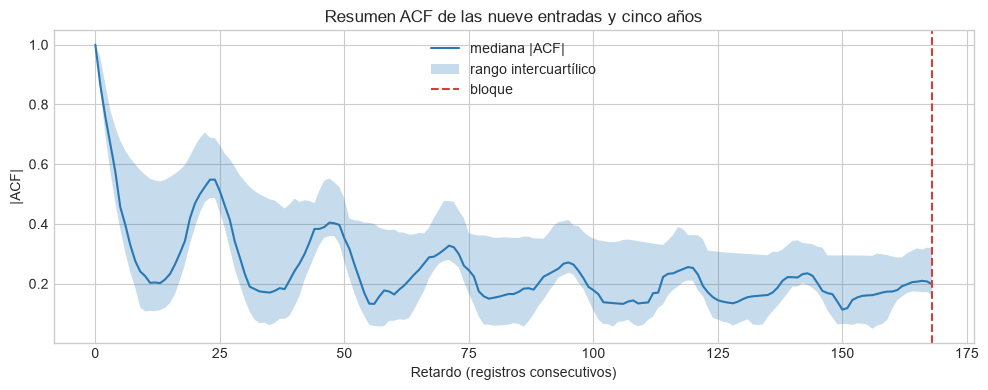

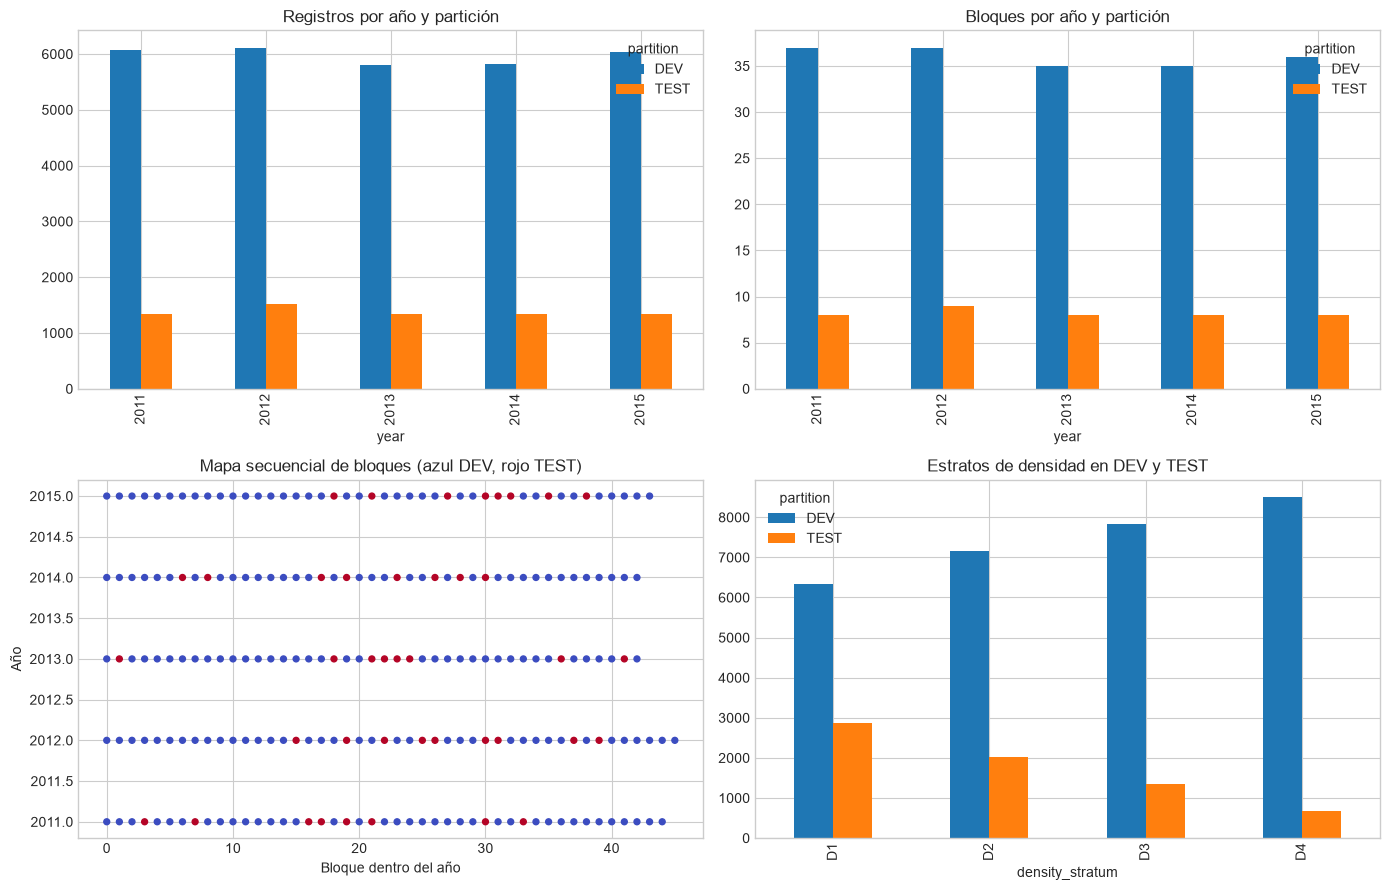

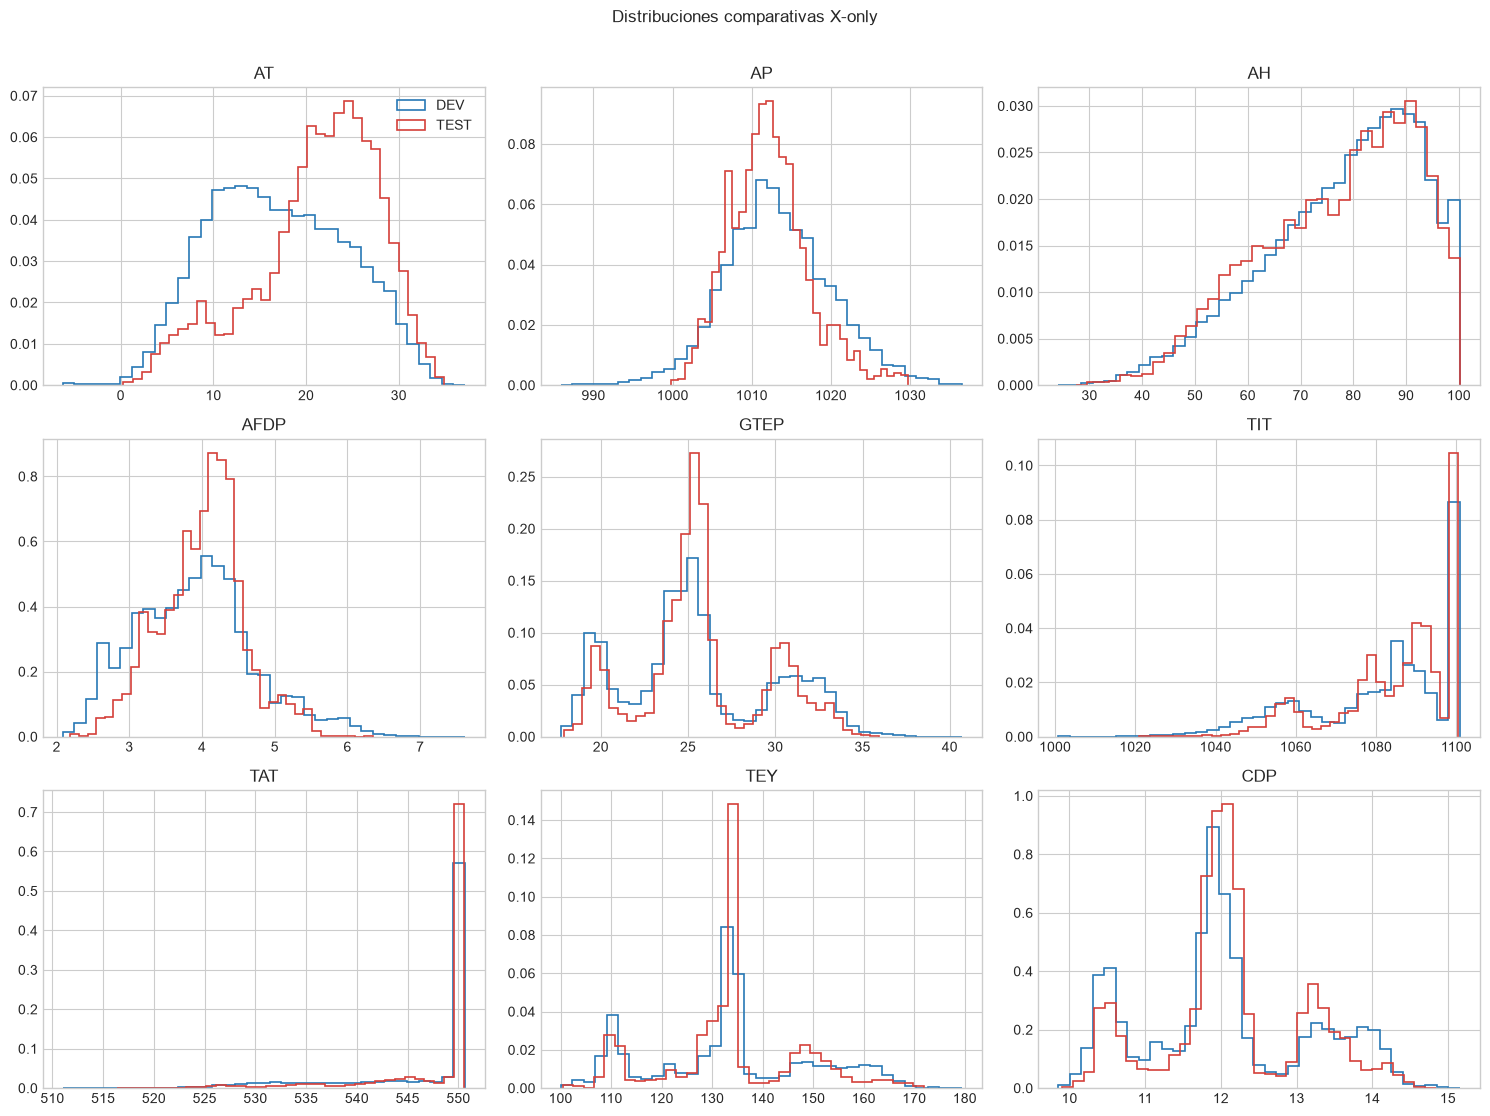

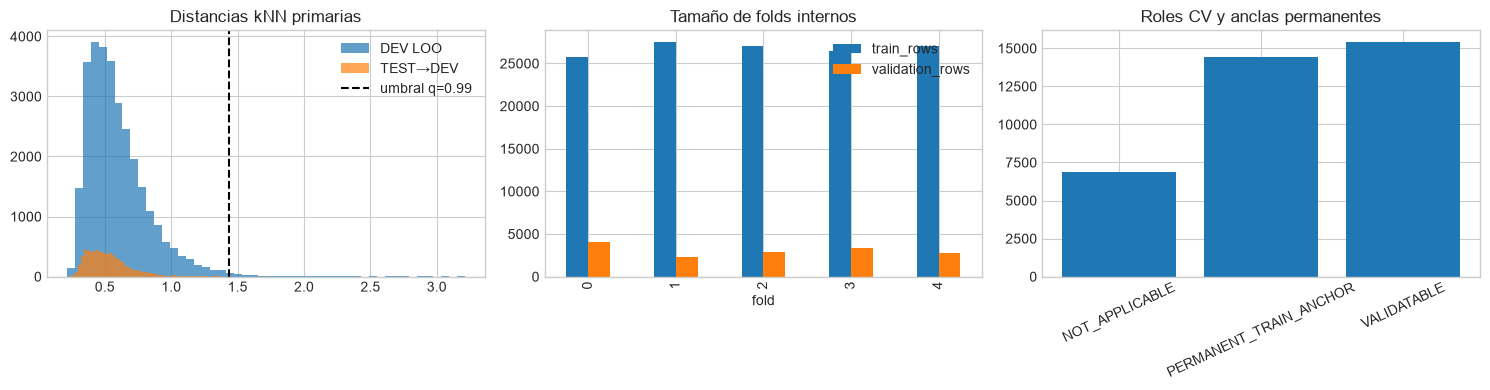

In [25]:
# [C-07.03] Ejecución de diagnósticos

SPLIT_DIAGNOSTICS = split_diagnostics(DATA, ASSIGNMENT, PATHS)
make_visualizations(DATA, ASSIGNMENT, EXTERNAL_EVAL, FINAL_FOLD_RESULTS, BLOCK_DIAGNOSTICS)


## SEC-08 — Comprobaciones finales de integridad

El protocolo solo puede congelarse si todos los invariantes científicos y de datos pasan.

### C-08.01 / CHK-15 — Auditoría de duplicados y pruebas integrales

**Objetivo:** verificar identidad, cobertura, bloques, folds, soporte, hashes y ceguera.
**Entradas:** todas las estructuras calculadas y hashes previos.
**Salidas:** checks, hashes posteriores y auditoría de duplicados X.
**Control:** CHK-15 — detener ante cualquier invariante fallido.


In [26]:
# [C-08.01] Auditoría de duplicados y pruebas integrales

def audit_exact_x_duplicates(
    data: pd.DataFrame,
    assignment: pd.DataFrame,
) -> dict:
    """Cuenta vectores X idénticos y detecta si cruzan DEV y TEST.

    La comparación usa los valores float64 leídos de las nueve columnas, sin redondeo.
    Un grupo duplicado puede permanecer dentro de una partición, pero nunca cruzarla.
    """
    joined = data[["global_row_id", *FEATURES]].merge(
        assignment[["global_row_id", "partition", "block_id"]],
        on="global_row_id",
        validate="one_to_one",
    )
    grouped = (
        joined.groupby(FEATURES, dropna=False, sort=False)
        .agg(
            rows=("global_row_id", "size"),
            partitions=("partition", "nunique"),
            blocks=("block_id", "nunique"),
        )
        .reset_index()
    )
    duplicate_groups = grouped.loc[grouped.rows > 1]
    crossing_groups = grouped.loc[grouped.partitions > 1]
    return {
        "comparison": "exact_float64_without_rounding",
        "duplicate_groups": int(len(duplicate_groups)),
        "duplicate_rows": int(duplicate_groups.rows.sum()),
        "duplicate_rows_fraction": float(duplicate_groups.rows.sum() / len(joined)),
        "cross_partition_groups": int(len(crossing_groups)),
        "cross_partition_rows": int(crossing_groups.rows.sum()),
        "cross_partition_rows_fraction": float(
            crossing_groups.rows.sum() / len(joined)
        ),
        "cross_block_groups": int((duplicate_groups.blocks > 1).sum()),
        "status": "PASS" if crossing_groups.empty else "FAIL",
    }


def test_integrity(
    data: pd.DataFrame,
    assignment: pd.DataFrame,
    test_blocks: set[str],
    assignments: dict[str, int],
    permanent: set[str],
    final_fold_results: list[dict],
    data_hashes_before: pd.DataFrame,
    root: Path,
):
    """Comprueba identidad, cobertura, duplicados X y ceguera de objetivos."""
    duplicate_audit = audit_exact_x_duplicates(data, assignment)
    checks = {
        "targets_absent_from_loaded_data": not set(PROTECTED_TARGETS) & set(data.columns),
        "unique_global_row_id": assignment.global_row_id.is_unique,
        "unique_global_position": assignment.global_position.is_unique,
        "complete_row_coverage": len(assignment) == EXPECTED_TOTAL_ROWS == len(data),
        "test_fraction_within_gate": (
            TEST_FRACTION_MIN
            <= float((assignment.partition == "TEST").mean())
            <= TEST_FRACTION_MAX
        ),
        "no_exact_x_duplicates_crossing_dev_test": (
            duplicate_audit["cross_partition_groups"] == 0
        ),
        "no_block_split_external": (
            assignment.groupby("block_id").partition.nunique().max() == 1
        ),
        "all_years_in_dev_and_test": (
            assignment.groupby(["year", "partition"])
            .size()
            .unstack(fill_value=0)
            .gt(0)
            .all()
            .all()
        ),
        "test_absent_from_folds": assignment.loc[assignment.partition == "TEST", "cv_fold"]
        .eq(-1)
        .all(),
        "anchors_in_dev": assignment.loc[assignment.is_feature_extreme_anchor, "partition"]
        .eq("DEV")
        .all(),
        "validatable_blocks_one_fold": assignment.loc[assignment.cv_role == "VALIDATABLE"]
        .groupby("block_id")
        .cv_fold.nunique()
        .eq(1)
        .all(),
        "permanent_anchors_fold_minus_one": assignment.loc[
            assignment.cv_role == "PERMANENT_TRAIN_ANCHOR", "cv_fold"
        ]
        .eq(-1)
        .all(),
        "marginal_test_100pct": assignment.loc[
            assignment.partition == "TEST", "test_marginal_in_dev_range"
        ].all(),
        "knn_test_100pct": assignment.loc[
            assignment.partition == "TEST", "test_multivariate_in_dev_support"
        ].all(),
        "dev_support_flags_are_not_applicable": assignment.loc[
            assignment.partition == "DEV",
            ["test_marginal_in_dev_range", "test_multivariate_in_dev_support"],
        ]
        .isna()
        .all()
        .all(),
        "five_folds": sorted(
            assignment.loc[assignment.cv_role == "VALIDATABLE", "cv_fold"].unique().tolist()
        )
        == list(range(N_FOLDS)),
        "fold_support_100pct": all(
            row["marginal_coverage"] == 1.0 and row["knn_coverage"] == 1.0
            for row in final_fold_results
        ),
    }

    sampled_blocks = sorted(assignment.block_id.unique())[
        :: max(1, assignment.block_id.nunique() // 10)
    ][:10]
    checks["sampled_blocks_indivisible"] = (
        assignment[assignment.block_id.isin(sampled_blocks)]
        .groupby("block_id")
        .partition.nunique()
        .eq(1)
        .all()
    )
    shuffled = (
        assignment.sample(frac=1, random_state=991)
        .set_index("global_row_id")
        .loc[assignment.global_row_id]
        .reset_index()
    )
    checks["id_reconstruction_after_shuffle"] = (
        shuffled.partition.tolist() == assignment.partition.tolist()
    )
    checks["same_seed_same_candidate_set"] = sample_test_blocks(
        data,
        set(data.loc[data.is_feature_extreme_anchor, "block_id"]),
        SPLIT_SEED,
    ) == sample_test_blocks(
        data,
        set(data.loc[data.is_feature_extreme_anchor, "block_id"]),
        SPLIT_SEED,
    )

    data_hashes_after = collect_data_hashes(root)
    checks["data_files_unchanged"] = data_hashes_before.equals(data_hashes_after)
    failed = [name for name, passed in checks.items() if not bool(passed)]
    if failed:
        raise AssertionError(f"Comprobaciones de integridad fallidas: {failed}")
    return checks, data_hashes_after, duplicate_audit


## SEC-09 — Persistencia, congelamiento y cierre

La asignación y los manifiestos forman la interfaz formal para los notebooks posteriores de NOx y CO.

### C-09.01 / ART-02 / ART-03 — Manifiestos de dominio y partición

**Objetivo:** construir la envolvente operativa y el contrato FROZEN de DEV/TEST.
**Entradas:** asignación, soporte, regla de bloques, sensibilidad y hashes.
**Salidas:** payloads de dominio y split.
**Control:** ART-02 / ART-03 — estado FROZEN y hashes canónicos.


In [27]:
# [C-09.01] Manifiestos de dominio y partición

def build_domain_envelope(external_eval: dict, sensitivity: pd.DataFrame) -> dict:
    return {
        "protocol_version": PROTOCOL_VERSION,
        "status": "FROZEN",
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "features": FEATURES,
        "dev_min": dict(zip(FEATURES, external_eval["dev_min"].tolist())),
        "dev_max": dict(zip(FEATURES, external_eval["dev_max"].tolist())),
        "standard_scaler_mean": dict(zip(FEATURES, external_eval["scaler"].mean_.tolist())),
        "standard_scaler_scale": dict(zip(FEATURES, external_eval["scaler"].scale_.tolist())),
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "knn_threshold": external_eval["threshold"],
        "dev_distance_summary": pd.Series(external_eval["dev_k"])
        .describe(percentiles=[0.5, 0.95, 0.99])
        .to_dict(),
        "test_distance_summary": pd.Series(external_eval["test_k"])
        .describe(percentiles=[0.5, 0.95, 0.99])
        .to_dict(),
        "sensitivity": sensitivity.to_dict(orient="records"),
        "external_model_required": False,
    }


def build_split_manifest(
    assignment: pd.DataFrame,
    block_rule: dict,
    anchor_detail: pd.DataFrame,
    external_eval: dict,
    permanent: set[str],
    data_hashes: pd.DataFrame,
    assignment_hash: str,
    duplicate_audit: dict,
) -> dict:
    annual = assignment.groupby(["year", "partition"]).size().unstack(fill_value=0)
    return {
        "protocol_version": PROTOCOL_VERSION,
        "status": "FROZEN",
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "scope": "Holdout interpolativo intradominio, X-aware y y-blind.",
        "features": FEATURES,
        "protected_targets": PROTECTED_TARGETS,
        "years": YEARS,
        "data_hashes": data_hashes[["year", "path", "sha256"]].to_dict(orient="records"),
        "total_rows": len(assignment),
        "split_seed": SPLIT_SEED,
        "nominal_test_fraction": TEST_TARGET_FRACTION,
        "actual_test_fraction": float((assignment.partition == "TEST").mean()),
        "test_fraction_gate": [TEST_FRACTION_MIN, TEST_FRACTION_MAX],
        "selection_design": (
            "annual balance with density-aware selection and post-hoc support gates"
        ),
        "exact_x_duplicate_audit": duplicate_audit,
        "annual_counts": {
            str(year): {key: int(value) for key, value in row.items()}
            for year, row in annual.to_dict(orient="index").items()
        },
        "block_rule": block_rule,
        "feature_extreme_anchor_blocks": int(anchor_detail.block_id.nunique()),
        "permanent_anchor_blocks": int(len(permanent)),
        "support_promotions": {
            "external_any_blocks": int(
                assignment.loc[assignment.is_external_support_promoted_anchor]
                .block_id.nunique()
            ),
            "external_knn_blocks": int(
                assignment.loc[assignment.promoted_by_knn].block_id.nunique()
            ),
            "external_marginal_blocks": int(
                assignment.loc[assignment.promoted_by_marginal_gate]
                .block_id.nunique()
            ),
            "internal_fold_blocks": int(
                assignment.loc[assignment.is_fold_support_promoted_anchor]
                .block_id.nunique()
            ),
        },
        "knn": {
            "k": KNN_K,
            "quantile": KNN_QUANTILE,
            "threshold": external_eval["threshold"],
        },
        "coverage": {
            "marginal": external_eval["marginal_coverage"],
            "knn": external_eval["knn_coverage"],
        },
        "row_assignment_sha256": assignment_hash,
        "warnings": [
            "No valida transferencia temporal.",
            "No equivale a certificación PEMS, RATA ni homologación regulatoria.",
        ],
    }


### C-09.02 / ART-04 — Manifiesto de folds internos

**Objetivo:** documentar cinco folds, anclas permanentes y hash canónico.
**Entradas:** asignación y resultados por fold.
**Salidas:** payload `INTERP_FOLDS_MANIFEST.json`.
**Control:** ART-04 — TEST ausente y soporte de folds aprobado.


In [28]:
# [C-09.02] Manifiesto de folds internos

def build_folds_manifest(
    assignment: pd.DataFrame,
    permanent: set[str],
    final_fold_results: list[dict],
    folds_hash: str,
) -> dict:
    return {
        "protocol_version": PROTOCOL_VERSION,
        "status": "FROZEN",
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "n_folds": N_FOLDS,
        "assignment_rule": (
            "Greedy grouped balancing by rows and year; X-only support promotion."
        ),
        "permanent_train_anchor_blocks": sorted(permanent),
        "counts_by_fold": final_fold_results,
        "disjoint_blocks": bool(
            assignment.loc[assignment.cv_role == "VALIDATABLE"]
            .groupby("block_id")
            .cv_fold.nunique()
            .eq(1)
            .all()
        ),
        "test_absent": bool(
            assignment.loc[assignment.partition == "TEST", "cv_fold"].eq(-1).all()
        ),
        "fold_support_all_pass": all(
            row["marginal_coverage"] == 1.0 and row["knn_coverage"] == 1.0
            for row in final_fold_results
        ),
        "fold_assignment_sha256": folds_hash,
    }


### C-09.03 / ART-05 — Guía de ejecución e informe técnico

**Objetivo:** producir documentación breve para ejecución y revisión externa.
**Entradas:** asignación, regla de bloques y cobertura.
**Salidas:** README e informe técnico en `reports/`.
**Control:** ART-05 — rutas canónicas y alcance declarados.


In [29]:
# [C-09.03] Guía de ejecución e informe técnico

def write_protocol_reports(
    paths: dict,
    assignment: pd.DataFrame,
    block_rule: dict,
    external_eval: dict,
    permanent: set[str],
) -> None:
    dev_rows = int((assignment.partition == "DEV").sum())
    test_rows = int((assignment.partition == "TEST").sum())
    readme = """# Ejecución en Google Colab

1. Conserve los CSV en `Turbine_Emissions_PINN/data/raw/`.
2. Abra `notebooks/00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb`.
3. Use **Runtime → Run all** con un entorno CPU.
4. Los resultados quedan en `models/interp/work_pinn_interp_protocol/`.

El notebook carga solamente las nueve variables operativas. Los nombres CO y NOX se
verifican en los encabezados, pero sus valores no se materializan.
"""
    report = f"""# Protocolo interpolativo común

El protocolo quedó **FROZEN** con {dev_rows:,} filas DEV y {test_rows:,} filas TEST.
El bloque seleccionado fue de {block_rule['selected_records']} registros consecutivos. La cobertura
marginal y kNN de TEST respecto de DEV fue {external_eval['marginal_coverage']:.2%}
y {external_eval['knn_coverage']:.2%}, respectivamente. Los cinco folds conservan
bloques completos y {len(permanent)} bloques como anclas permanentes de entrenamiento.

El resultado es un holdout intradominio diseñado para los modelos posteriores de NOx
y CO. No constituye validación prospectiva ni certificación regulatoria.
"""
    atomic_text(paths["reports"] / "README_EJECUCION_COLAB_INTERP_PROTOCOL.md", readme)
    atomic_text(paths["reports"] / "INFORME_TECNICO_INTERP_PROTOCOL.md", report)


### C-09.04 / ART-06 — Persistencia atómica del protocolo

**Objetivo:** escribir asignación, manifiestos, auditorías, reportes y hashes finales.
**Entradas:** resultados aprobados por CHK-15.
**Salidas:** conjunto completo de artefactos FROZEN.
**Control:** CHK-16 — validaciones finales y hashes SHA-256.


In [30]:
# [C-09.04] Persistencia atómica del protocolo

def persist_protocol(
    output_dir: Path,
    paths: dict,
    assignment: pd.DataFrame,
    block_rule: dict,
    anchor_detail: pd.DataFrame,
    external_eval: dict,
    sensitivity: pd.DataFrame,
    permanent: set[str],
    final_fold_results: list[dict],
    checks: dict,
    data_hashes_after: pd.DataFrame,
    duplicate_audit: dict,
    elapsed_seconds: float,
):
    """Congela la asignación y los manifiestos consumidos por otros notebooks."""
    assignment_path = paths["tables"] / "INTERP_ROW_ASSIGNMENT.csv"
    atomic_csv(assignment_path, assignment)
    assignment_hash = sha256_file(assignment_path)

    fold_payload = (
        assignment.loc[assignment.partition == "DEV", ["block_id", "cv_role", "cv_fold"]]
        .drop_duplicates()
        .sort_values("block_id")
    )
    folds_hash = sha256_bytes(
        fold_payload.to_csv(index=False, lineterminator="\n").encode("utf-8")
    )
    envelope = build_domain_envelope(external_eval, sensitivity)
    split_manifest = build_split_manifest(
        assignment,
        block_rule,
        anchor_detail,
        external_eval,
        permanent,
        data_hashes_after,
        assignment_hash,
        duplicate_audit,
    )
    folds_manifest = build_folds_manifest(
        assignment,
        permanent,
        final_fold_results,
        folds_hash,
    )

    atomic_json(paths["manifests"] / "INTERP_DOMAIN_ENVELOPE.json", envelope)
    atomic_json(paths["manifests"] / "INTERP_SPLIT_MANIFEST.json", split_manifest)
    atomic_json(paths["manifests"] / "INTERP_FOLDS_MANIFEST.json", folds_manifest)
    atomic_csv(paths["audit"] / "INTERP_DATA_HASHES_AFTER.csv", data_hashes_after)
    atomic_json(paths["audit"] / "INTERP_EXACT_X_DUPLICATES_AUDIT.json", duplicate_audit)
    write_protocol_reports(paths, assignment, block_rule, external_eval, permanent)
    atomic_json(
        paths["audit"] / "LAST_RUN_RUNTIME.json",
        {
            "last_run_finished_at_utc": utc_now(),
            "elapsed_seconds": elapsed_seconds,
        },
    )

    excluded = {
        paths["audit"] / "HASHES_ARTEFACTOS_INTERP_PROTOCOL.csv",
        paths["manifests"] / "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json",
        paths["audit"] / "LAST_RUN_RUNTIME.json",
    }
    artifact_paths = [
        path
        for path in sorted(output_dir.rglob("*"))
        if path.is_file() and path not in excluded
    ]
    artifact_hashes = pd.DataFrame(
        [
            {
                "path": str(path.relative_to(output_dir)),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
            for path in artifact_paths
        ]
    )
    atomic_csv(paths["audit"] / "HASHES_ARTEFACTOS_INTERP_PROTOCOL.csv", artifact_hashes)
    general_manifest = {
        "protocol_version": PROTOCOL_VERSION,
        "status": "FROZEN",
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "artifact_count": len(artifact_hashes),
        "artifacts": artifact_hashes.to_dict(orient="records"),
    }
    atomic_json(
        paths["manifests"] / "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json",
        general_manifest,
    )

    validations = {
        "integridad_de_datos": bool(checks["data_files_unchanged"]),
        "ceguera_de_objetivos": bool(checks["targets_absent_from_loaded_data"]),
        "cobertura_completa": bool(checks["complete_row_coverage"]),
        "fraccion_test_en_rango": bool(checks["test_fraction_within_gate"]),
        "sin_duplicados_x_cruzados": bool(
            checks["no_exact_x_duplicates_crossing_dev_test"]
        ),
        "banderas_soporte_aplicables_solo_a_test": bool(
            checks["dev_support_flags_are_not_applicable"]
        ),
        "bloques_indivisibles": bool(checks["no_block_split_external"]),
        "cobertura_marginal": bool(checks["marginal_test_100pct"]),
        "soporte_knn": bool(checks["knn_test_100pct"]),
        "cinco_folds_validos": bool(checks["five_folds"] and checks["fold_support_100pct"]),
    }
    if not all(validations.values()):
        failed = [name for name, passed in validations.items() if not passed]
        raise AssertionError(f"Validaciones finales fallidas: {failed}")
    return split_manifest, folds_manifest, envelope, validations, artifact_hashes


### C-09.05 / OUT-08 — Congelamiento y resumen final

**Objetivo:** ejecutar controles, persistir artefactos y presentar el handoff del protocolo.
**Entradas:** asignación, folds, envolvente, auditorías y rutas.
**Salidas:** manifiestos FROZEN, tabla de hashes y resumen final.
**Control:** OUT-08 — estado, tamaños, coberturas, hashes, duración y ruta de salida.


In [31]:
# [C-09.05] Congelamiento y resumen final

print("Fase 5/5 · Validación y congelamiento de artefactos")
INTEGRITY_CHECKS, DATA_HASHES_AFTER, EXACT_X_DUPLICATE_AUDIT = test_integrity(
    DATA,
    ASSIGNMENT,
    TEST_BLOCKS,
    FOLD_ASSIGNMENTS,
    PERMANENT_ANCHORS,
    FINAL_FOLD_RESULTS,
    DATA_HASHES_BEFORE,
    PROJECT_ROOT,
)
RUN_ELAPSED_SECONDS = time.perf_counter() - RUN_STARTED
(
    SPLIT_MANIFEST,
    FOLDS_MANIFEST,
    DOMAIN_ENVELOPE,
    VALIDATIONS,
    ARTIFACT_HASHES,
) = persist_protocol(
    OUTPUT_DIR,
    PATHS,
    ASSIGNMENT,
    BLOCK_RULE,
    FEATURE_ANCHOR_DETAIL,
    EXTERNAL_EVAL,
    KNN_SENSITIVITY,
    PERMANENT_ANCHORS,
    FINAL_FOLD_RESULTS,
    INTEGRITY_CHECKS,
    DATA_HASHES_AFTER,
    EXACT_X_DUPLICATE_AUDIT,
    RUN_ELAPSED_SECONDS,
)

summary = pd.DataFrame(
    [
        {
            "estado": SPLIT_MANIFEST["status"],
            "filas totales": len(ASSIGNMENT),
            "filas DEV": int((ASSIGNMENT.partition == "DEV").sum()),
            "filas TEST": int((ASSIGNMENT.partition == "TEST").sum()),
            "registros por bloque": BLOCK_SIZE_RECORDS,
            "cobertura marginal": EXTERNAL_EVAL["marginal_coverage"],
            "cobertura kNN": EXTERNAL_EVAL["knn_coverage"],
            "hash de asignación": SPLIT_MANIFEST["row_assignment_sha256"],
            "hash de folds": FOLDS_MANIFEST["fold_assignment_sha256"],
            "duración (s)": RUN_ELAPSED_SECONDS,
        }
    ]
)
display(summary.T.rename(columns={0: "resultado"}))
print(f"Artefactos guardados en: {OUTPUT_DIR}")


Fase 5/5 · Validación y congelamiento de artefactos


,resultado
estado,FROZEN
filas totales,36733
filas DEV,29845
filas TEST,6888
registros por bloque,168
cobertura marginal,1.0
cobertura kNN,1.0
hash de asignación,1a1706f37198468e010c066361444072daddf979543bd4...
hash de folds,b3c660c84099fff3da15ce90b5346c9b52eee2357fd05a...
duración (s),93.141993


Artefactos guardados en: C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_interp_protocol
